<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/dynamiccompressor_dyn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dynamic compressor maps and anti-surge control with NeqSim

This notebook repairs and extends the existing **Dynamic compressor and antisurge** catalog example. It is intended for process, machinery, and control engineers who want a reproducible bridge between real-gas compressor calculations and dynamic anti-surge logic.

**Prerequisites:** basic thermodynamics, centrifugal-compressor terminology, Python, and feedback-control concepts. All displayed engineering quantities use SI units, with bara retained as the customary absolute-pressure reporting unit.

## Learning objectives

After completing the notebook, you can:

1. build an SRK natural-gas model and a NeqSim compressor;
2. generate and interrogate a native multi-speed compressor chart;
3. calculate surge and stone-wall margins with the released API;
4. compare native `AntiSurge` control strategies;
5. integrate recycle-valve dynamics with sequential NeqSim operating points;
6. verify a turndown and recovery scenario with machinery, controller, and numerical checks; and
7. return a machine-readable operating snapshot for monitoring or automation.

## 1. Engineering context and scope

A centrifugal compressor becomes difficult to operate when flow falls toward the surge line. Surge is a system instability involving flow reversal and pressure oscillation; a steady compressor map can identify proximity but cannot reproduce a complete surge cycle by itself.

The practical protection layer is an anti-surge recycle valve. It raises flow through the compressor while net export flow is low. This example combines:

- native NeqSim SRK thermodynamics and compressor-chart interpolation;
- native surge, stone-wall, `AntiSurge`, and operating-history APIs; and
- an explicit, inspectable time integration for the demand, speed, recycle, and valve-response logic.

It is a screening and teaching model, not a substitute for vendor maps, piping acoustics, valve sizing, or high-fidelity dynamic simulation.

## 2. Governing measures

The fractional surge margin compares compressor volumetric flow $Q$ with surge-line flow $Q_s$ at the current map state:

$$
SM = \frac{Q-Q_s}{Q_s}
$$

Positive $SM$ is on the stable-flow side of the surge line. The control line includes a factor $F_s>1$:

$$
Q_{control} = F_s Q_s
$$

This notebook uses $F_s=1.10$, corresponding to a nominal 10% control-line allowance. The value is an editable study criterion, not a universal machinery guarantee.

## 3. Recycle and actuator dynamics

Recycle increases flow through the compressor without increasing fresh export:

$$
\dot{m}_{comp} = \dot{m}_{fresh} + \dot{m}_{recycle}
$$

The native anti-surge controller returns a bounded valve position. A first-order hydraulic response is applied to the recycle mass flow:

$$
\frac{d\dot{m}_{recycle}}{dt}
= \frac{\dot{m}_{target}-\dot{m}_{recycle}}{\tau_r}
$$

Here $	au_r$ is a documented two-second recycle-flow response time. It prevents an unrealistic instantaneous flow jump.

## 4. Compressor energy

NeqSim evaluates real-gas inlet and outlet enthalpies and compressor performance. The thermodynamic power basis is:

$$
\dot{W} = \dot{m}_{comp}(h_2-h_1)
$$

where $\dot{W}$ is power in W, $\dot{m}_{comp}$ is compressor mass flow in kg/s, and $h_1$ and $h_2$ are specific enthalpies in J/kg. The generated chart supplies speed-dependent head and efficiency; NeqSim then returns power and discharge temperature.

## 5. Assumptions, units, and validity limits

- Gas composition is synthetic and normalized to 100 mol%.
- SRK with the classic mixing rule is used because this dry hydrocarbon gas is far from aqueous association.
- Suction conditions are fixed at 35 bara and 25 °C.
- The chart is generated from a reproducible NeqSim `EXPORT` template around a 9000 rpm design point. Replace it with vendor-corrected data for project work.
- Fresh flow changes from 12 to 5 kg/s and later recovers.
- The scheduled speed response has a 15 s time constant; shaft torque and rotor inertia are not solved.
- Recycle piping pressure drop, cooler thermal inertia, valve characteristic, and acoustic surge cycles are outside scope.
- A positive computed margin is necessary but not sufficient evidence of safe compressor operation.

## 6. Clean Colab setup

In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

## 7. Imports and runtime record

In [2]:
import json
import math
import platform
import subprocess
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neqsim import jneqsim
from neqsim.process import clearProcess
from neqsim.process import compressor
from neqsim.process import runProcess
from neqsim.process import stream
from neqsim.thermo import fluid


neqsim_version = version("neqsim")
python_version = platform.python_version()
java_version = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    check=True,
    text=True,
).stderr.splitlines()[0]

plt.rcParams.update(
    {
        "axes.grid": True,
        "figure.dpi": 110,
        "grid.alpha": 0.25,
    }
)

print(f"NeqSim version: {neqsim_version}")
print(f"Python version: {python_version}")
print(f"Java runtime: {java_version}")

NeqSim version: 3.16.0
Python version: 3.12.13
Java runtime: openjdk version "17.0.19" 2026-04-21


## 8. Define the gas

The fluid object stores composition, equation of state, mixing rule, and state. Streams copy and transport that thermodynamic model into process equipment. Initializing the phase properties before process construction gives an independent check of composition, molar mass, density, and compressibility.

In [3]:
GAS_COMPOSITION_MOL_PERCENT = {
    "nitrogen": 1.0,
    "CO2": 2.0,
    "methane": 89.0,
    "ethane": 6.0,
    "propane": 2.0,
}

SUCTION_PRESSURE_BARA = 35.0
SUCTION_TEMPERATURE_C = 25.0
DESIGN_FLOW_KG_S = 12.0
DESIGN_SPEED_RPM = 9000.0
NOMINAL_DISCHARGE_PRESSURE_BARA = 80.0


def build_gas():
    gas = fluid("srk")

    for component_name, mole_percent in (
        GAS_COMPOSITION_MOL_PERCENT.items()
    ):
        gas.addComponent(component_name, mole_percent)

    gas.setMixingRule("classic")
    return gas


gas_check = build_gas()
gas_check.setTemperature(SUCTION_TEMPERATURE_C, "C")
gas_check.setPressure(SUCTION_PRESSURE_BARA, "bara")
gas_check.init(3)
gas_check.initPhysicalProperties()

fluid_checks = pd.Series(
    {
        "composition sum (mol%)": sum(
            GAS_COMPOSITION_MOL_PERCENT.values()
        ),
        "molar mass (kg/mol)": gas_check.getMolarMass(),
        "gas density (kg/m3)": (
            gas_check.getPhase(0).getDensity("kg/m3")
        ),
        "compressibility factor (-)": gas_check.getPhase(0).getZ(),
    },
    name="suction-fluid audit",
)
display(fluid_checks)

composition sum (mol%)        100.000000
molar mass (kg/mol)             0.018125
gas density (kg/m3)            27.603337
compressibility factor (-)      0.928398
Name: suction-fluid audit, dtype: float64

## 9. Build the NeqSim compressor and generated chart

`stream` supplies the boundary condition. `compressor` performs the real-gas machinery calculation. `CompressorChartGenerator` builds five speed curves from the tested `EXPORT` template. The generated surge and stone-wall curves make operating-envelope methods active.

The nominal outlet pressure is used to establish the initial design calculation. Once the chart is attached, chart head and efficiency determine the resulting operating point for each flow and speed.

In [4]:
clearProcess()
feed = stream("export-compressor inlet", build_gas())
feed.setFlowRate(DESIGN_FLOW_KG_S, "kg/sec")
feed.setTemperature(SUCTION_TEMPERATURE_C, "C")
feed.setPressure(SUCTION_PRESSURE_BARA, "bara")

machine = compressor("K-100 export compressor", feed)
machine.setOutletPressure(
    NOMINAL_DISCHARGE_PRESSURE_BARA,
    "bara",
)
machine.setUsePolytropicCalc(True)
machine.setPolytropicEfficiency(0.78)
machine.setSpeed(DESIGN_SPEED_RPM)
runProcess()

generator_class = (
    jneqsim.process.equipment.compressor.CompressorChartGenerator
)
chart_generator = generator_class(machine)
chart_generator.setChartType("interpolate and extrapolate")
compressor_chart = chart_generator.generateFromTemplate("EXPORT", 5)
compressor_chart.generateSurgeCurve()
compressor_chart.generateStoneWallCurve()
machine.setCompressorChart(compressor_chart)
machine.enableOperatingHistory()
machine.run()

print(
    "Generated speed curves:",
    len(compressor_chart.getSpeeds()),
)

Generated speed curves: 5


## 10. Inspect the base operating point

The chart-active compressor exposes flow, head, efficiency, power, discharge conditions, surge flow, and both boundary margins. Positive surge and stone-wall distances indicate that this selected base point lies between the two map limits.

In [5]:
def current_operating_point():
    return {
        "compressor flow (kg/s)": feed.getFlowRate("kg/sec"),
        "actual flow (m3/hr)": feed.getFlowRate("m3/hr"),
        "speed (rpm)": machine.getSpeed(),
        "head (kJ/kg)": machine.getPolytropicHead("kJ/kg"),
        "efficiency (-)": machine.getPolytropicEfficiency(),
        "power (kW)": machine.getPower("kW"),
        "discharge pressure (bara)": (
            machine.getOutletStream().getPressure("bara")
        ),
        "discharge temperature (°C)": (
            machine.getOutletStream().getTemperature("C")
        ),
        "surge flow (m3/hr)": machine.getSurgeFlowRate(),
        "surge margin (%)": 100.0 * machine.getDistanceToSurge(),
        "stone-wall margin (%)": (
            100.0 * machine.getDistanceToStoneWall()
        ),
    }


base_point = current_operating_point()
display(pd.Series(base_point, name="chart-active base point").round(6))

compressor flow (kg/s)          12.000000
actual flow (m3/hr)           1565.028184
speed (rpm)                   9000.000000
head (kJ/kg)                   119.950145
efficiency (-)                   0.800000
power (kW)                    1799.252173
discharge pressure (bara)       81.833060
discharge temperature (°C)     101.441507
surge flow (m3/hr)            1033.966149
surge margin (%)                51.361646
stone-wall margin (%)           46.878445
Name: chart-active base point, dtype: float64

## 11. Visual model and solver workflow

The workflow separates machinery physics from control integration. Every dynamic step updates fresh flow, scheduled speed, and recycle flow; NeqSim then evaluates a new map-aware compressor point. The native anti-surge controller reads the resulting margin and returns the next valve command.

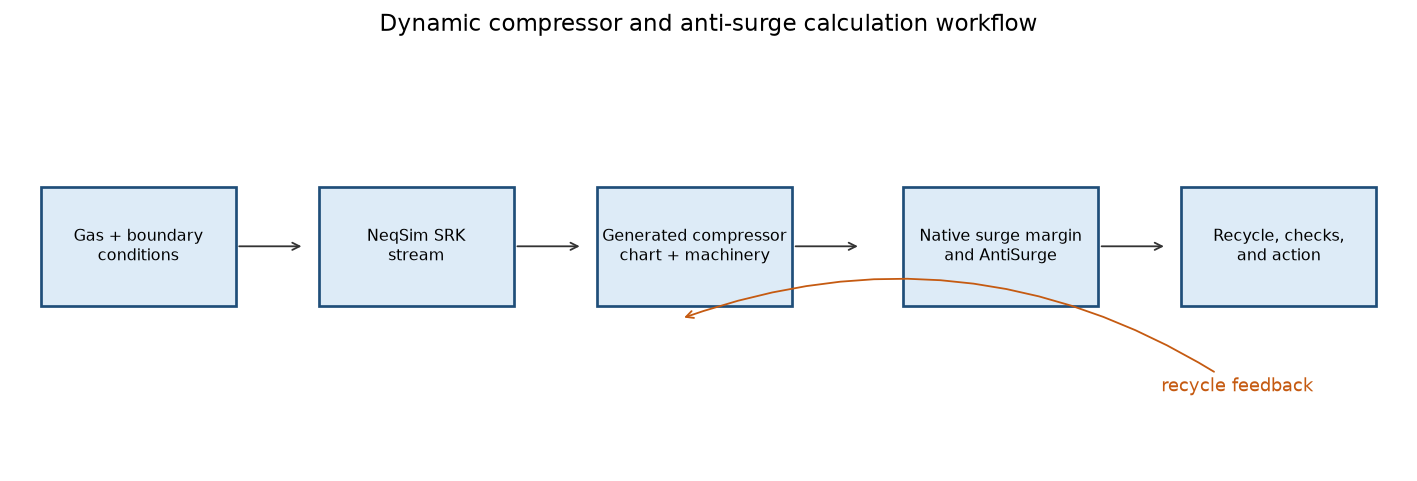

In [6]:
figure, axis = plt.subplots(figsize=(11.0, 3.8))
axis.axis("off")

workflow_boxes = [
    (0.02, "Gas + boundary\nconditions"),
    (0.22, "NeqSim SRK\nstream"),
    (0.42, "Generated compressor\nchart + machinery"),
    (0.64, "Native surge margin\nand AntiSurge"),
    (0.84, "Recycle, checks,\nand action"),
]

for x_position, label in workflow_boxes:
    axis.add_patch(
        plt.Rectangle(
            (x_position, 0.38),
            0.14,
            0.28,
            facecolor="#DDEBF7",
            edgecolor="#1F4E79",
            linewidth=1.5,
        )
    )
    axis.text(
        x_position + 0.07,
        0.52,
        label,
        ha="center",
        va="center",
        fontsize=9,
    )

for x_position in [0.16, 0.36, 0.56, 0.78]:
    axis.annotate(
        "",
        xy=(x_position + 0.05, 0.52),
        xytext=(x_position, 0.52),
        arrowprops={"arrowstyle": "->", "color": "#333333"},
    )

axis.annotate(
    "recycle feedback",
    xy=(0.48, 0.35),
    xytext=(0.88, 0.18),
    ha="center",
    arrowprops={
        "arrowstyle": "->",
        "connectionstyle": "arc3,rad=0.25",
        "color": "#C55A11",
    },
    color="#C55A11",
)
axis.set_title(
    "Dynamic compressor and anti-surge calculation workflow",
    fontsize=13,
)
figure.tight_layout()
plt.show()

## 12. Map sweep with native margins

The sweep changes flow and speed while preserving the same gas and suction state. Each point is recalculated by NeqSim. This tests interpolation, exposes the stable map region, and supplies data for the engineering plot.

In [7]:
map_records = []
MAP_SPEEDS_RPM = [7500.0, 8250.0, 9000.0, 9750.0, 10500.0]
MAP_FLOWS_KG_S = np.linspace(5.0, 17.0, 13)

for speed_rpm in MAP_SPEEDS_RPM:
    for flow_kg_s in MAP_FLOWS_KG_S:
        feed.setFlowRate(float(flow_kg_s), "kg/sec")
        feed.run()
        machine.setSpeed(speed_rpm)
        machine.run()

        point = current_operating_point()
        point["requested flow (kg/s)"] = flow_kg_s
        map_records.append(point)

compressor_map = pd.DataFrame(map_records)
display(
    compressor_map.groupby("speed (rpm)")[
        [
            "head (kJ/kg)",
            "efficiency (-)",
            "surge margin (%)",
            "stone-wall margin (%)",
        ]
    ].agg(["min", "max"]).round(4)
)

head (kJ/kg)            ... stone-wall margin (%)          
                     min       max  ...                   min       max
speed (rpm)                         ...                                
7500.0           28.6236   90.7636  ...              -49.6922  198.2325
8250.0           48.8088  113.2123  ...              -36.1071  240.0195
9000.0           75.1324  137.4635  ...              -20.3937  284.9696
9750.0           81.3934  148.9188  ...              -17.3302  306.2022
10500.0          87.6545  160.3741  ...              -14.0115  327.4348

[5 rows x 8 columns]

## 13. Compressor map interpretation

Solid curves are generated speed lines. The dashed surge boundary is obtained from `getSurgeFlowRate()` at each point; the dotted stone-wall boundary is reconstructed from the returned fractional distance. Stable screening points have both margins above zero.

Extrapolated portions are useful for visualization but must not be treated as vendor-certified operating space.

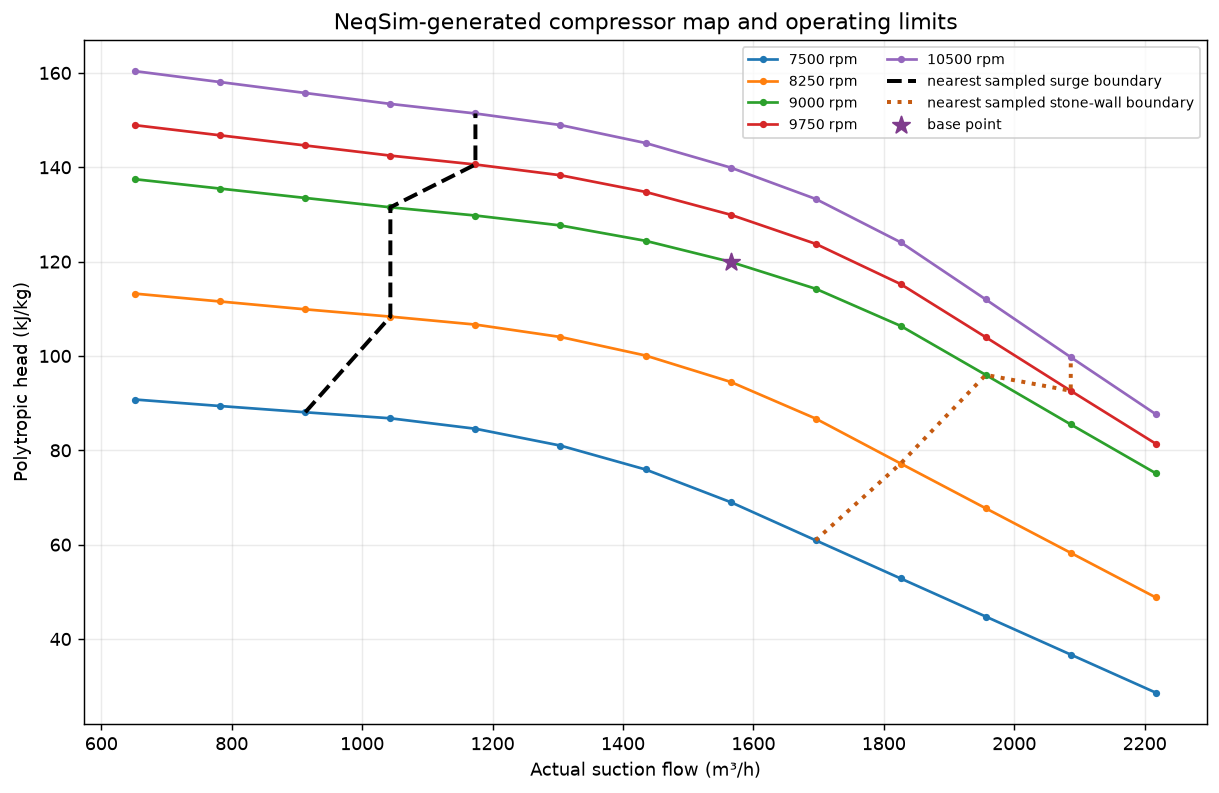

In [8]:
figure, axis = plt.subplots(figsize=(9.5, 6.2))

for speed_rpm, group in compressor_map.groupby("speed (rpm)"):
    ordered = group.sort_values("actual flow (m3/hr)")
    axis.plot(
        ordered["actual flow (m3/hr)"],
        ordered["head (kJ/kg)"],
        marker="o",
        markersize=3,
        label=f"{speed_rpm:.0f} rpm",
    )

surge_boundary = (
    compressor_map.groupby("speed (rpm)")
    .apply(
        lambda group: group.iloc[
            group["surge margin (%)"].abs().argmin()
        ],
        include_groups=False,
    )
    .sort_index()
)
stone_boundary = (
    compressor_map.groupby("speed (rpm)")
    .apply(
        lambda group: group.iloc[
            group["stone-wall margin (%)"].abs().argmin()
        ],
        include_groups=False,
    )
    .sort_index()
)

axis.plot(
    surge_boundary["actual flow (m3/hr)"],
    surge_boundary["head (kJ/kg)"],
    color="black",
    linestyle="--",
    linewidth=2.2,
    label="nearest sampled surge boundary",
)
axis.plot(
    stone_boundary["actual flow (m3/hr)"],
    stone_boundary["head (kJ/kg)"],
    color="#C55A11",
    linestyle=":",
    linewidth=2.2,
    label="nearest sampled stone-wall boundary",
)
axis.scatter(
    base_point["actual flow (m3/hr)"],
    base_point["head (kJ/kg)"],
    s=100,
    marker="*",
    color="#7F3C8D",
    label="base point",
    zorder=6,
)
axis.set_xlabel("Actual suction flow (m³/h)")
axis.set_ylabel("Polytropic head (kJ/kg)")
axis.set_title("NeqSim-generated compressor map and operating limits")
axis.legend(ncol=2, fontsize=8)
figure.tight_layout()
plt.show()

## 14. Native anti-surge strategy response

NeqSim 3.16.0 provides `ON_OFF`, `PROPORTIONAL`, `PID`, `PREDICTIVE`, and `DUAL_LOOP` controller strategies. The next cell applies the same prescribed surge-margin approach and recovery to four strategies. This isolates controller behavior before closing the loop around the compressor calculation.

In [9]:
control_strategy = (
    jneqsim.process.equipment.compressor.AntiSurge.ControlStrategy
)
anti_surge = machine.getAntiSurge()
anti_surge.setActive(True)
anti_surge.setSurgeControlFactor(1.10)
anti_surge.setSurgeWarningMargin(0.10)
anti_surge.setValveResponseTime(2.0)
anti_surge.setValveRateLimit(0.30)
anti_surge.setPIDSetpoint(0.10)
anti_surge.setPIDParameters(1.0, 0.15, 0.0)

strategy_margin = np.concatenate(
    [
        np.linspace(0.35, -0.05, 31),
        np.linspace(-0.05, 0.25, 31),
    ]
)
strategy_records = []

for strategy_name in [
    "ON_OFF",
    "PROPORTIONAL",
    "PID",
    "PREDICTIVE",
]:
    anti_surge.resetPID()
    anti_surge.setValvePosition(0.0)
    strategy = control_strategy.valueOf(strategy_name)
    anti_surge.setControlStrategy(strategy)

    for step, margin in enumerate(strategy_margin):
        valve_position = anti_surge.updateController(
            float(margin),
            1.0,
        )
        strategy_records.append(
            {
                "time (s)": float(step),
                "strategy": strategy_name,
                "surge margin (%)": 100.0 * margin,
                "valve position (%)": 100.0 * valve_position,
            }
        )

strategy_response = pd.DataFrame(strategy_records)
display(
    strategy_response.groupby("strategy")[
        "valve position (%)"
    ].agg(["max", "mean"]).round(3)
)

,max,mean
strategy,,
ON_OFF,99.999,45.154
PID,34.404,14.751
PREDICTIVE,99.764,46.687
PROPORTIONAL,99.764,46.687


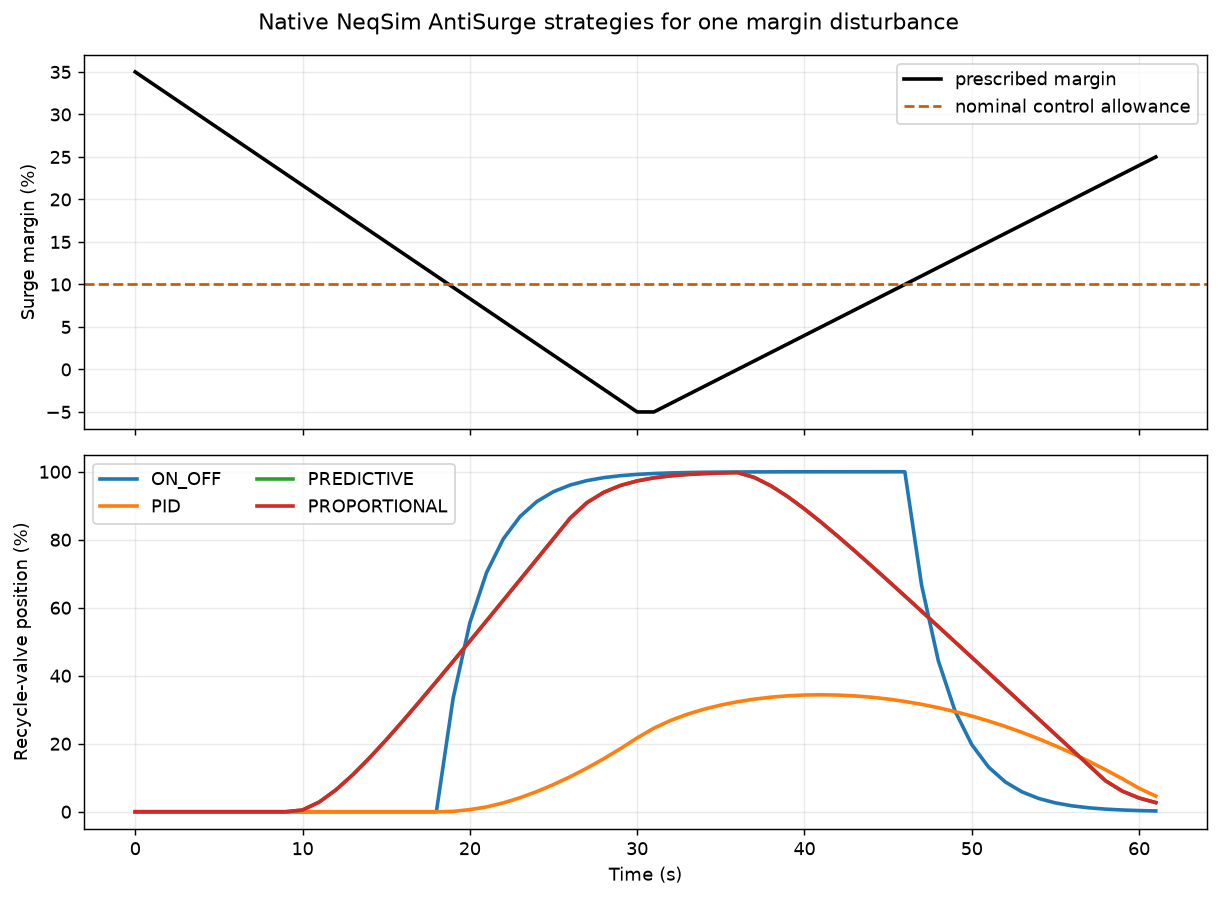

In [10]:
figure, axes = plt.subplots(
    2,
    1,
    figsize=(9.5, 7.0),
    sharex=True,
)
axes[0].plot(
    np.arange(len(strategy_margin)),
    100.0 * strategy_margin,
    color="black",
    linewidth=2.0,
    label="prescribed margin",
)
axes[0].axhline(
    10.0,
    color="#C55A11",
    linestyle="--",
    label="nominal control allowance",
)
axes[0].set_ylabel("Surge margin (%)")
axes[0].legend()

for strategy_name, group in strategy_response.groupby("strategy"):
    axes[1].plot(
        group["time (s)"],
        group["valve position (%)"],
        linewidth=2.0,
        label=strategy_name,
    )

axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Recycle-valve position (%)")
axes[1].legend(ncol=2)
figure.suptitle(
    "Native NeqSim AntiSurge strategies for one margin disturbance"
)
figure.tight_layout()
plt.show()

## 15. Dynamic turndown schedules

Fresh flow ramps from 12 to 5 kg/s, remains at turndown, and then recovers. Speed is scheduled down to reduce power but responds with a 15 s time constant. This schedule is deterministic so controlled and uncontrolled cases are directly comparable.

In [11]:
TIME_STEP_S = 1.0
DURATION_S = 260.0
SPEED_RESPONSE_TIME_S = 15.0
RECYCLE_RESPONSE_TIME_S = 2.0


def fresh_flow_schedule(time_s):
    if time_s < 40.0:
        return 12.0

    if time_s < 80.0:
        return 12.0 - 7.0 * (time_s - 40.0) / 40.0

    if time_s < 180.0:
        return 5.0

    if time_s < 220.0:
        return 5.0 + 7.0 * (time_s - 180.0) / 40.0

    return 12.0


def target_speed_schedule(time_s):
    load_fraction = fresh_flow_schedule(time_s) / DESIGN_FLOW_KG_S
    return 7800.0 + 1200.0 * load_fraction


schedule_table = pd.DataFrame(
    {
        "time (s)": [0.0, 40.0, 80.0, 180.0, 220.0, 260.0],
    }
)
schedule_table["fresh flow (kg/s)"] = schedule_table[
    "time (s)"
].map(fresh_flow_schedule)
schedule_table["target speed (rpm)"] = schedule_table[
    "time (s)"
].map(target_speed_schedule)
display(schedule_table)

,time (s),fresh flow (kg/s),target speed (rpm)
0,0.0,12.0,9000.0
1,40.0,12.0,9000.0
2,80.0,5.0,8300.0
3,180.0,5.0,8300.0
4,220.0,12.0,9000.0
5,260.0,12.0,9000.0


## 16. Reusable closed-loop simulator

At each one-second step, the function:

1. evaluates fresh-flow and speed targets;
2. calculates total compressor flow including recycle;
3. reruns the native NeqSim compressor;
4. reads native surge and stone-wall margins;
5. updates the native proportional anti-surge controller; and
6. integrates the explicit recycle-flow lag.

The returned table contains every intermediate quantity needed to audit or replace the control assumptions.

In [12]:
def simulate_turndown(
    anti_surge_enabled,
    maximum_recycle_kg_s=8.0,
):
    anti_surge.resetPID()
    anti_surge.setActive(anti_surge_enabled)
    anti_surge.setControlStrategy(control_strategy.PROPORTIONAL)
    anti_surge.setValvePosition(0.0)
    history = machine.getOperatingHistory()
    history.clear()

    recycle_flow_kg_s = 0.0
    speed_rpm = DESIGN_SPEED_RPM
    records = []

    for time_s in np.arange(
        0.0,
        DURATION_S + TIME_STEP_S,
        TIME_STEP_S,
    ):
        fresh_flow_kg_s = fresh_flow_schedule(time_s)
        target_speed_rpm = target_speed_schedule(time_s)
        speed_rpm += (
            target_speed_rpm - speed_rpm
        ) * TIME_STEP_S / SPEED_RESPONSE_TIME_S
        compressor_flow_kg_s = (
            fresh_flow_kg_s + recycle_flow_kg_s
        )

        feed.setFlowRate(float(compressor_flow_kg_s), "kg/sec")
        feed.run()
        machine.setSpeed(float(speed_rpm))
        machine.run()
        machine.recordOperatingPoint(float(time_s))

        surge_margin = float(machine.getDistanceToSurge())

        if anti_surge_enabled:
            valve_position = float(
                anti_surge.updateController(
                    surge_margin,
                    TIME_STEP_S,
                )
            )
        else:
            valve_position = 0.0

        recycle_target_kg_s = (
            maximum_recycle_kg_s * valve_position
        )
        recycle_flow_kg_s += (
            recycle_target_kg_s - recycle_flow_kg_s
        ) * TIME_STEP_S / RECYCLE_RESPONSE_TIME_S

        records.append(
            {
                "time (s)": time_s,
                "fresh flow (kg/s)": fresh_flow_kg_s,
                "recycle flow (kg/s)": recycle_flow_kg_s,
                "compressor flow (kg/s)": compressor_flow_kg_s,
                "speed (rpm)": speed_rpm,
                "recycle-valve position (%)": (
                    100.0 * valve_position
                ),
                "surge margin (%)": 100.0 * surge_margin,
                "stone-wall margin (%)": (
                    100.0 * machine.getDistanceToStoneWall()
                ),
                "actual flow (m3/hr)": feed.getFlowRate("m3/hr"),
                "head (kJ/kg)": (
                    machine.getPolytropicHead("kJ/kg")
                ),
                "efficiency (%)": (
                    100.0 * machine.getPolytropicEfficiency()
                ),
                "power (kW)": machine.getPower("kW"),
                "discharge pressure (bara)": (
                    machine.getOutletStream().getPressure("bara")
                ),
                "discharge temperature (°C)": (
                    machine.getOutletStream().getTemperature("C")
                ),
            }
        )

    response = pd.DataFrame(records)
    history_summary = {
        "point count": history.getPointCount(),
        "minimum native history surge margin (-)": (
            history.getMinimumSurgeMargin()
        ),
    }
    return response, history_summary

## 17. Controlled and uncontrolled cases

The no-recycle case deliberately shows why fresh-flow turndown is unsafe. The controlled case uses exactly the same gas, map, flow schedule, speed schedule, and time step; only the anti-surge recycle is enabled.

In [13]:
uncontrolled_response, uncontrolled_history = (
    simulate_turndown(False)
)
controlled_response, controlled_history = simulate_turndown(True)
controlled_snapshot_json = machine.getOperatingPointJson()

case_summary = pd.DataFrame(
    {
        "without recycle": {
            "minimum surge margin (%)": uncontrolled_response[
                "surge margin (%)"
            ].min(),
            "maximum recycle (kg/s)": uncontrolled_response[
                "recycle flow (kg/s)"
            ].max(),
            "peak power (kW)": uncontrolled_response[
                "power (kW)"
            ].max(),
        },
        "with native AntiSurge": {
            "minimum surge margin (%)": controlled_response[
                "surge margin (%)"
            ].min(),
            "maximum recycle (kg/s)": controlled_response[
                "recycle flow (kg/s)"
            ].max(),
            "peak power (kW)": controlled_response[
                "power (kW)"
            ].max(),
        },
    }
).T
display(case_summary.round(4))

,minimum surge margin (%),maximum recycle (kg/s),peak power (kW)
without recycle,-36.4969,0.0000,1799.2522
with native AntiSurge,9.0587,3.6618,1799.2522


## 18. Time-history interpretation

The recycle valve begins opening as margin approaches the 10% control allowance. Compressor flow remains above fresh flow during turndown. When demand returns, the valve closes and speed recovers. Power and discharge temperature respond to both speed and recycled throughput.

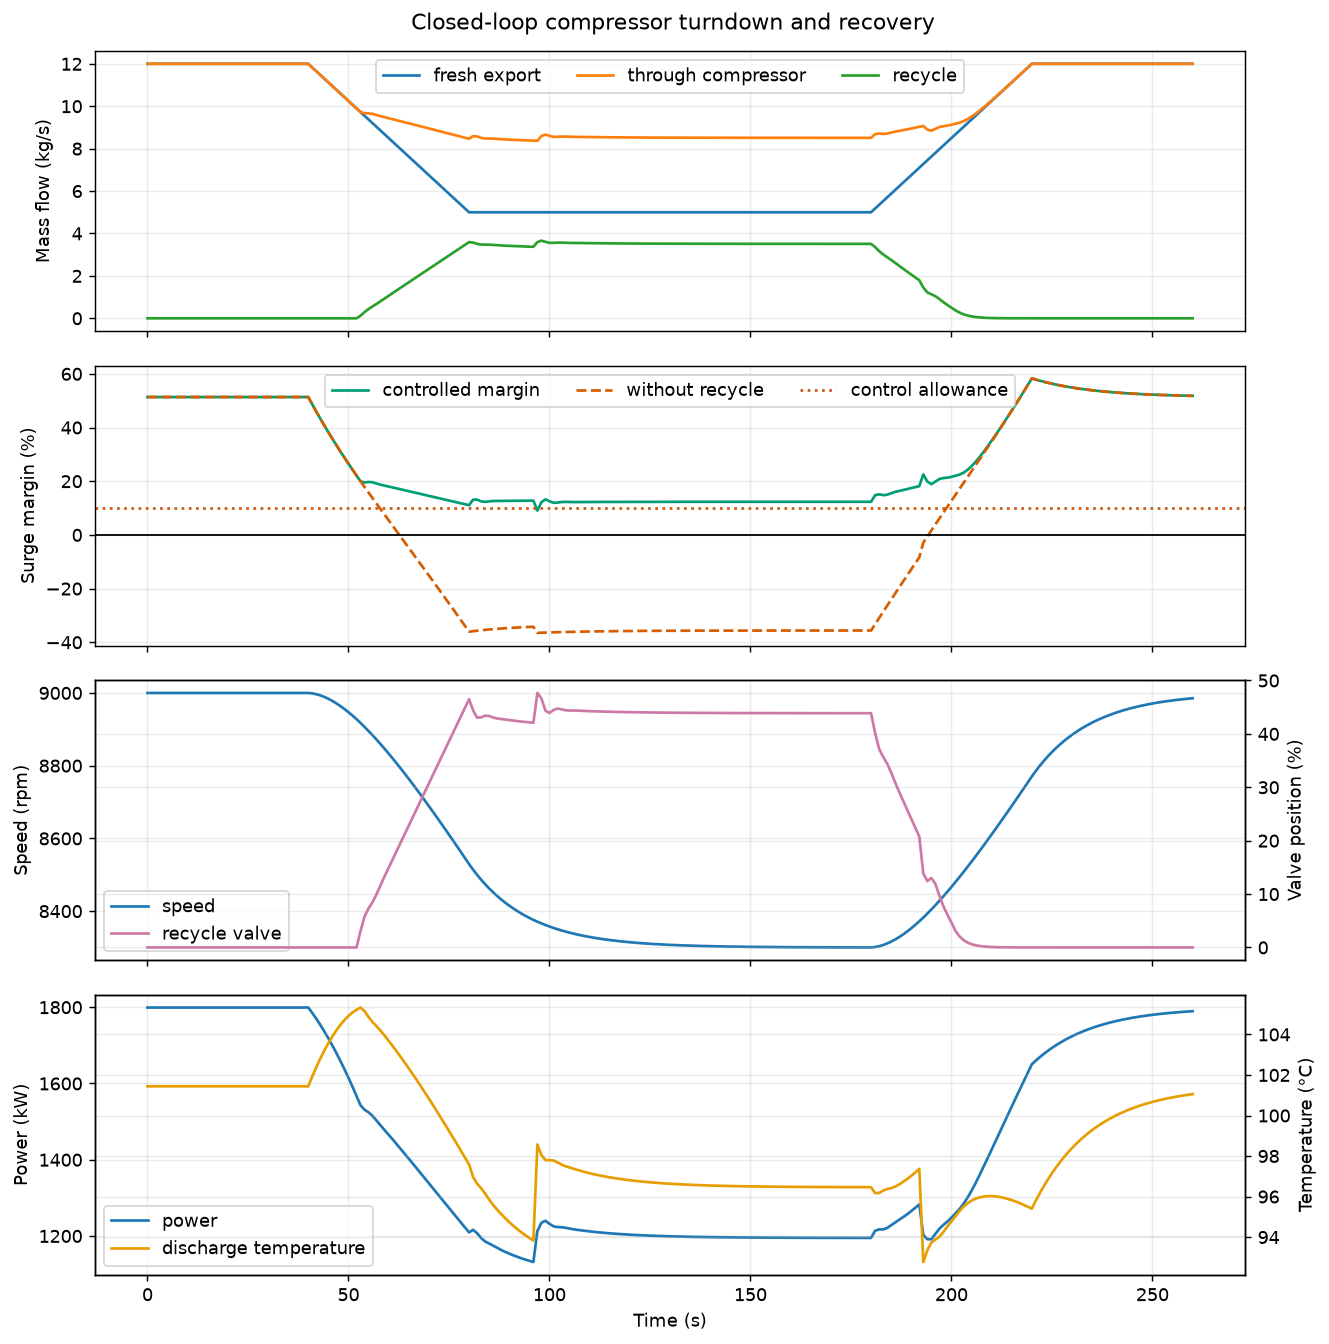

In [14]:
figure, axes = plt.subplots(
    4,
    1,
    figsize=(10.5, 10.5),
    sharex=True,
)
axes[0].plot(
    controlled_response["time (s)"],
    controlled_response["fresh flow (kg/s)"],
    label="fresh export",
)
axes[0].plot(
    controlled_response["time (s)"],
    controlled_response["compressor flow (kg/s)"],
    label="through compressor",
)
axes[0].plot(
    controlled_response["time (s)"],
    controlled_response["recycle flow (kg/s)"],
    label="recycle",
)
axes[0].set_ylabel("Mass flow (kg/s)")
axes[0].legend(ncol=3)

axes[1].plot(
    controlled_response["time (s)"],
    controlled_response["surge margin (%)"],
    color="#009E73",
    label="controlled margin",
)
axes[1].plot(
    uncontrolled_response["time (s)"],
    uncontrolled_response["surge margin (%)"],
    color="#D55E00",
    linestyle="--",
    label="without recycle",
)
axes[1].axhline(0.0, color="black", linewidth=1.0)
axes[1].axhline(
    10.0,
    color="#C55A11",
    linestyle=":",
    label="control allowance",
)
axes[1].set_ylabel("Surge margin (%)")
axes[1].legend(ncol=3)

speed_line = axes[2].plot(
    controlled_response["time (s)"],
    controlled_response["speed (rpm)"],
    label="speed",
)[0]
valve_axis = axes[2].twinx()
valve_line = valve_axis.plot(
    controlled_response["time (s)"],
    controlled_response["recycle-valve position (%)"],
    color="#CC79A7",
    label="recycle valve",
)[0]
axes[2].set_ylabel("Speed (rpm)")
valve_axis.set_ylabel("Valve position (%)")
axes[2].legend(
    [speed_line, valve_line],
    ["speed", "recycle valve"],
    loc="best",
)

power_line = axes[3].plot(
    controlled_response["time (s)"],
    controlled_response["power (kW)"],
    label="power",
)[0]
temperature_axis = axes[3].twinx()
temperature_line = temperature_axis.plot(
    controlled_response["time (s)"],
    controlled_response["discharge temperature (°C)"],
    color="#E69F00",
    label="discharge temperature",
)[0]
axes[3].set_xlabel("Time (s)")
axes[3].set_ylabel("Power (kW)")
temperature_axis.set_ylabel("Temperature (°C)")
axes[3].legend(
    [power_line, temperature_line],
    ["power", "discharge temperature"],
    loc="best",
)
figure.suptitle(
    "Closed-loop compressor turndown and recovery"
)
figure.tight_layout()
plt.show()

## 19. Operating trajectory on the generated map

The trajectory moves left as fresh flow falls. Recycle bends it back toward the stable side of the surge boundary. The colored time sequence helps diagnose whether the recycle action occurs before or after the operating point crosses the desired control allowance.

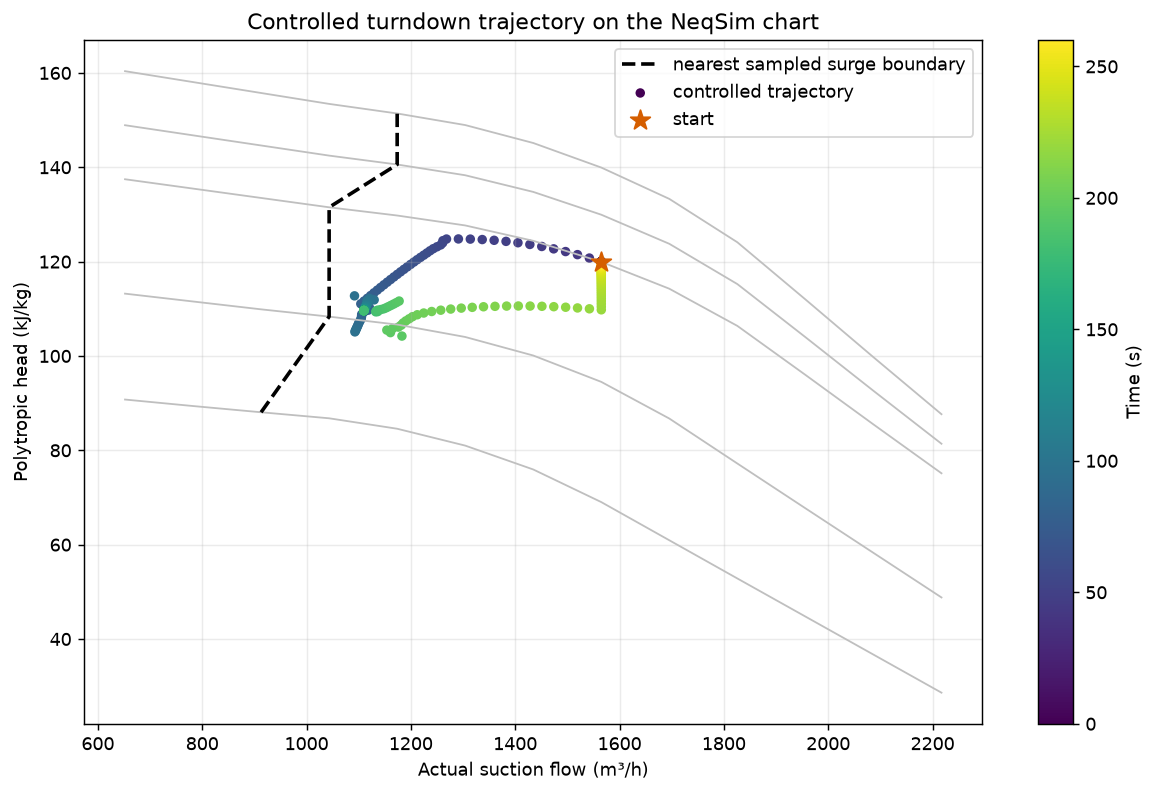

In [15]:
figure, axis = plt.subplots(figsize=(9.5, 6.2))

for speed_rpm, group in compressor_map.groupby("speed (rpm)"):
    ordered = group.sort_values("actual flow (m3/hr)")
    axis.plot(
        ordered["actual flow (m3/hr)"],
        ordered["head (kJ/kg)"],
        color="0.75",
        linewidth=1.0,
    )

axis.plot(
    surge_boundary["actual flow (m3/hr)"],
    surge_boundary["head (kJ/kg)"],
    color="black",
    linestyle="--",
    linewidth=2.0,
    label="nearest sampled surge boundary",
)
trajectory = axis.scatter(
    controlled_response["actual flow (m3/hr)"],
    controlled_response["head (kJ/kg)"],
    c=controlled_response["time (s)"],
    cmap="viridis",
    s=18,
    label="controlled trajectory",
)
axis.scatter(
    controlled_response["actual flow (m3/hr)"].iloc[0],
    controlled_response["head (kJ/kg)"].iloc[0],
    marker="*",
    s=130,
    color="#D55E00",
    label="start",
    zorder=5,
)
figure.colorbar(trajectory, ax=axis, label="Time (s)")
axis.set_xlabel("Actual suction flow (m³/h)")
axis.set_ylabel("Polytropic head (kJ/kg)")
axis.set_title("Controlled turndown trajectory on the NeqSim chart")
axis.legend()
figure.tight_layout()
plt.show()

## 20. Recycle-capacity sensitivity

Controller logic cannot compensate for an undersized recycle path. Three maximum recycle capacities are tested with identical disturbances. The selected 8 kg/s case is sufficient for the 10% control allowance after the initial actuator transient; smaller capacities leave less margin.

These capacities are mass-flow limits in this synthetic study, not valve sizing results.

In [16]:
capacity_records = []

for maximum_recycle_kg_s in [2.0, 4.0, 8.0]:
    response, _ = simulate_turndown(
        True,
        maximum_recycle_kg_s=maximum_recycle_kg_s,
    )
    low_flow_window = response["time (s)"].between(100.0, 180.0)
    capacity_records.append(
        {
            "maximum recycle (kg/s)": maximum_recycle_kg_s,
            "minimum overall margin (%)": response[
                "surge margin (%)"
            ].min(),
            "minimum settled turndown margin (%)": response.loc[
                low_flow_window,
                "surge margin (%)",
            ].min(),
            "maximum valve position (%)": response[
                "recycle-valve position (%)"
            ].max(),
            "maximum actual recycle (kg/s)": response[
                "recycle flow (kg/s)"
            ].max(),
            "mean turndown power (kW)": response.loc[
                low_flow_window,
                "power (kW)",
            ].mean(),
        }
    )

capacity_sensitivity = pd.DataFrame(capacity_records)
display(capacity_sensitivity.round(4))

,maximum recycle (kg/s),minimum overall margin (%),minimum settled turndown margin (%),maximum valve position (%),maximum actual recycle (kg/s),mean turndown power (kW)
0,2.0,-18.2113,-17.8739,100.0000,2.0000,1191.7293
1,4.0,0.4633,3.4406,87.2854,3.4281,1318.2570
2,8.0,7.4833,10.8993,52.9864,4.0694,1383.5773


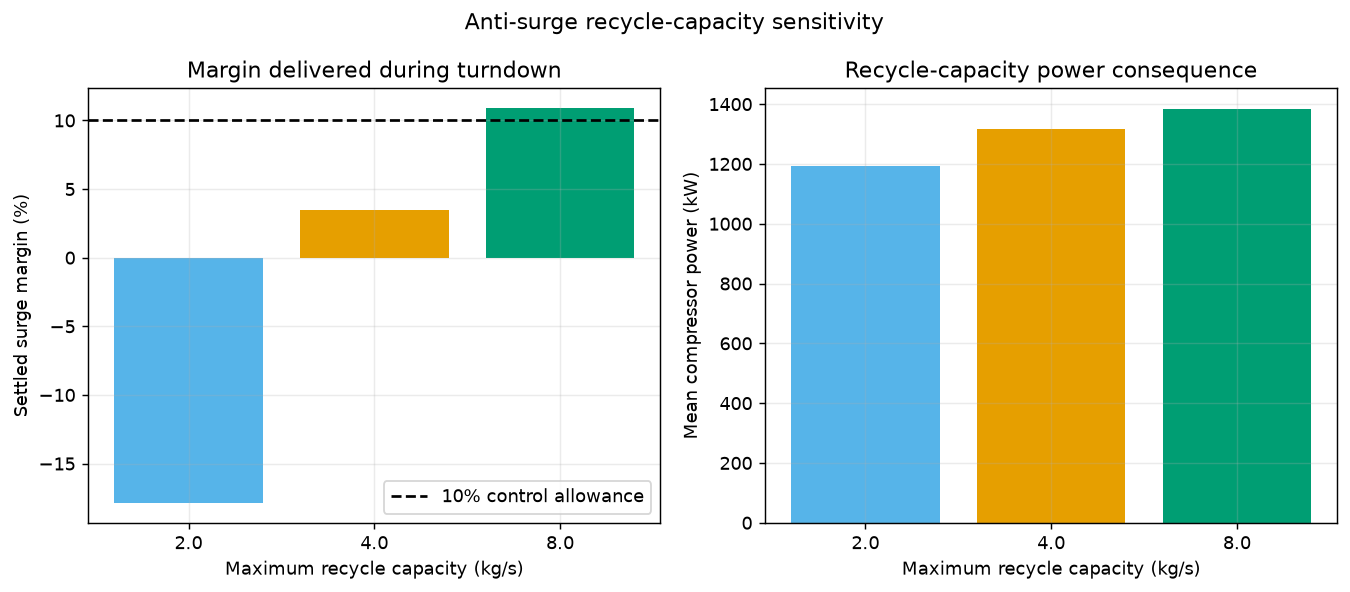

In [17]:
figure, axes = plt.subplots(1, 2, figsize=(10.5, 4.6))
bar_colors = ["#56B4E9", "#E69F00", "#009E73"]

axes[0].bar(
    capacity_sensitivity["maximum recycle (kg/s)"].astype(str),
    capacity_sensitivity[
        "minimum settled turndown margin (%)"
    ],
    color=bar_colors,
)
axes[0].axhline(
    10.0,
    color="black",
    linestyle="--",
    label="10% control allowance",
)
axes[0].set_xlabel("Maximum recycle capacity (kg/s)")
axes[0].set_ylabel("Settled surge margin (%)")
axes[0].set_title("Margin delivered during turndown")
axes[0].legend()

axes[1].bar(
    capacity_sensitivity["maximum recycle (kg/s)"].astype(str),
    capacity_sensitivity["mean turndown power (kW)"],
    color=bar_colors,
)
axes[1].set_xlabel("Maximum recycle capacity (kg/s)")
axes[1].set_ylabel("Mean compressor power (kW)")
axes[1].set_title("Recycle-capacity power consequence")
figure.suptitle("Anti-surge recycle-capacity sensitivity")
figure.tight_layout()
plt.show()

## 21. Machine-readable operating result

`getOperatingPointJson()` returns the current native compressor result with schema version, flow, head, speed, efficiency, power, discharge state, map status, margins, and limiting constraint. This is useful for online monitoring, APIs, digital twins, and agentic workflows. The notebook adds its study-level criteria without modifying the native payload.

In [18]:
native_snapshot = json.loads(str(controlled_snapshot_json))
engineering_snapshot = {
    "native_compressor": native_snapshot,
    "study": {
        "scenario": "12-to-5-to-12 kg/s turndown",
        "minimum_controlled_surge_margin_percent": float(
            controlled_response["surge margin (%)"].min()
        ),
        "maximum_recycle_kg_s": float(
            controlled_response["recycle flow (kg/s)"].max()
        ),
        "peak_power_kw": float(
            controlled_response["power (kW)"].max()
        ),
        "history_point_count": int(
            controlled_history["point count"]
        ),
    },
}

snapshot_table = pd.Series(
    {
        "native schema version": native_snapshot["schemaVersion"],
        "chart active": native_snapshot["chartActive"],
        "within chart": native_snapshot["withinChart"],
        "final native limiting constraint": (
            native_snapshot["limitingConstraint"]
        ),
        "controlled history points": (
            controlled_history["point count"]
        ),
        "minimum controlled margin (%)": (
            engineering_snapshot["study"][
                "minimum_controlled_surge_margin_percent"
            ]
        ),
    },
    name="reusable compressor-health snapshot",
)
display(snapshot_table)

native schema version                    1.1
chart active                            True
within chart                            True
final native limiting constraint        none
controlled history points                261
minimum controlled margin (%)       9.058681
Name: reusable compressor-health snapshot, dtype: object

## 22. Verification philosophy

Checks cover four layers:

- **fluid:** composition closure and plausible real-gas properties;
- **machinery:** positive head, power, efficiency, and base margins;
- **control:** recycle activates, improves minimum margin, and closes after recovery;
- **numerics:** finite trajectories, complete time grid, native history count, and meaningful sensitivity trends.

Passing assertions show internal consistency for this stated basis. They do not certify a compressor or anti-surge system.

In [19]:
checks = []


def record_check(condition, description):
    assert condition, description
    checks.append(description)


record_check(neqsim_version == "3.16.0", "tested NeqSim version")
record_check(
    abs(fluid_checks["composition sum (mol%)"] - 100.0) < 1.0e-12,
    "composition closure",
)
record_check(
    0.015 < fluid_checks["molar mass (kg/mol)"] < 0.030,
    "plausible natural-gas molar mass",
)
record_check(
    0.75 < fluid_checks["compressibility factor (-)"] < 1.05,
    "plausible suction compressibility",
)
record_check(base_point["head (kJ/kg)"] > 0.0, "positive base head")
record_check(base_point["power (kW)"] > 0.0, "positive base power")
record_check(
    0.60 < base_point["efficiency (-)"] < 0.90,
    "plausible base efficiency",
)
record_check(
    base_point["discharge temperature (°C)"] > SUCTION_TEMPERATURE_C,
    "compression raises gas temperature",
)
record_check(
    base_point["surge margin (%)"] > 0.0,
    "base point above surge line",
)
record_check(
    base_point["stone-wall margin (%)"] > 0.0,
    "base point below stone wall",
)
record_check(
    np.isfinite(compressor_map.select_dtypes("number")).all().all(),
    "finite map sweep",
)
record_check(
    len(controlled_response) == 261,
    "complete controlled time grid",
)
record_check(
    np.isfinite(
        controlled_response.select_dtypes("number")
    ).all().all(),
    "finite controlled trajectory",
)
record_check(
    controlled_response["recycle flow (kg/s)"].max() > 3.0,
    "recycle activates during turndown",
)
record_check(
    controlled_response["surge margin (%)"].min()
    > uncontrolled_response["surge margin (%)"].min() + 30.0,
    "anti-surge materially improves minimum margin",
)
record_check(
    controlled_response["surge margin (%)"].min() > 5.0,
    "controlled margin remains positive during actuator transient",
)
record_check(
    controlled_response["recycle flow (kg/s)"].iloc[-1] < 1.0e-3,
    "recycle closes after recovery",
)
record_check(
    controlled_history["point count"] == len(controlled_response),
    "native operating history contains every controlled point",
)
record_check(
    capacity_sensitivity[
        "minimum settled turndown margin (%)"
    ].is_monotonic_increasing,
    "settled margin increases with recycle capacity",
)
record_check(
    capacity_sensitivity["maximum actual recycle (kg/s)"].max()
    <= 8.0 + 1.0e-6,
    "recycle flow respects selected maximum capacity",
)
record_check(native_snapshot["chartActive"], "native chart active")
record_check(
    native_snapshot["schemaVersion"] == "1.1",
    "native operating-point schema version",
)

print(f"All {len(checks)} engineering checks passed.")
print(
    "Minimum controlled surge margin:",
    f"{controlled_response['surge margin (%)'].min():.6f}%",
)
print(
    "Minimum uncontrolled surge margin:",
    f"{uncontrolled_response['surge margin (%)'].min():.6f}%",
)
print(
    "Maximum controlled recycle:",
    f"{controlled_response['recycle flow (kg/s)'].max():.6f} kg/s",
)

All 22 engineering checks passed.
Minimum controlled surge margin: 9.058681%
Minimum uncontrolled surge margin: -36.496917%
Maximum controlled recycle: 3.661828 kg/s


## 23. Preserved source workflows and figures

The modern native-API application above is followed by all five connected-process workflows from the source notebook. This section is deliberately substantial: preservation is part of the engineering audit, and each of the 30 original figure purposes is recalculated with the tested NeqSim release.

### Preservation inventory

The source revision contained **19 cells, five dynamic workflows, and 30 substantive figures**. Every source cell remains in this notebook in the same order. The code has been reformatted and its labels corrected, but each original speed-step, pressure-control, recycle-control, combined-control, depressurization, startup, and map calculation remains executable.

In [20]:
import importlib.util

import pandas as pd
from IPython.display import display

assert importlib.util.find_spec("neqsim") is not None
print("Reusing the NeqSim environment initialized above.")


def display_legacy_diagnostics(
    compressor,
    feed_stream,
    export_valve,
    surge_monitor=None,
    recycle_valve=None,
):
    diagnostics = {
        "speed (rpm)": compressor.getSpeed(),
        "feed flow (kg/h)": feed_stream.getFlowRate("kg/hr"),
        "compressor flow (kg/h)": compressor.getInletStream().getFlowRate(
            "kg/hr"
        ),
        "export flow (kg/h)": export_valve.getOutletStream().getFlowRate(
            "kg/hr"
        ),
        "suction pressure (bara)": compressor.getInletStream().getPressure(),
        "discharge pressure (bara)": (
            compressor.getOutletStream().getPressure()
        ),
    }

    if surge_monitor is not None:
        diagnostics["distance to surge (-)"] = surge_monitor.getMeasuredValue(
            "distance to surge"
        )
    if recycle_valve is not None:
        diagnostics["recycle flow (kg/h)"] = (
            recycle_valve.getOutletStream().getFlowRate("kg/hr")
        )
        diagnostics["recycle valve position (%)"] = (
            recycle_valve.getPercentValveOpening()
        )

    display(pd.Series(diagnostics, name="preserved workflow diagnostics"))


Reusing the NeqSim environment initialized above.


Related foundation: [Introduction to dynamic process simulations in NeqSim](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/dynamicsimul.ipynb).

The preserved workflows below use native NeqSim `ProcessSystem.runTransient()` calculations. They complement the released `AntiSurge` API workflow above by showing connected valves, separators, recycle equipment, transmitters, and generic PI controllers.

## Preserved connected-process compressor calculations

These source examples retain their original teaching sequence while using readable Python, corrected units, descriptive figure titles, and current NeqSim 3.16.0 APIs.

The original examples demonstrate how vessel inventory, throttling valves, compressor speed, recycle, and PI controllers interact in a connected dynamic process. Their generated compressor chart is intentionally synthetic; use vendor-corrected curves and project control narratives for design work.

### Preserved example 1 — response to increasing compressor speed

A 200 rpm speed step is applied after the two-separator process reaches its initial dynamic state. The expected response is higher compressor flow, lower suction-separator pressure, and higher discharge-side pressure. Three original figures are retained: separator pressures, the dynamic flow–head trajectory, and a map comparison.

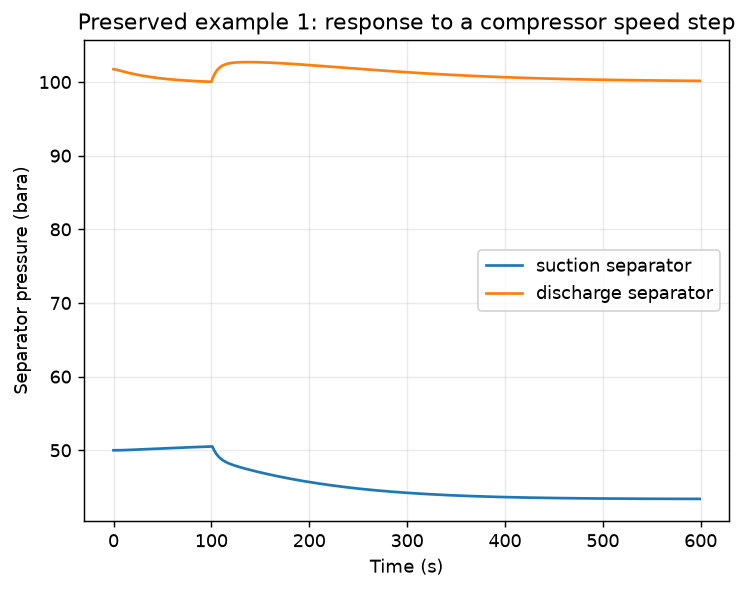

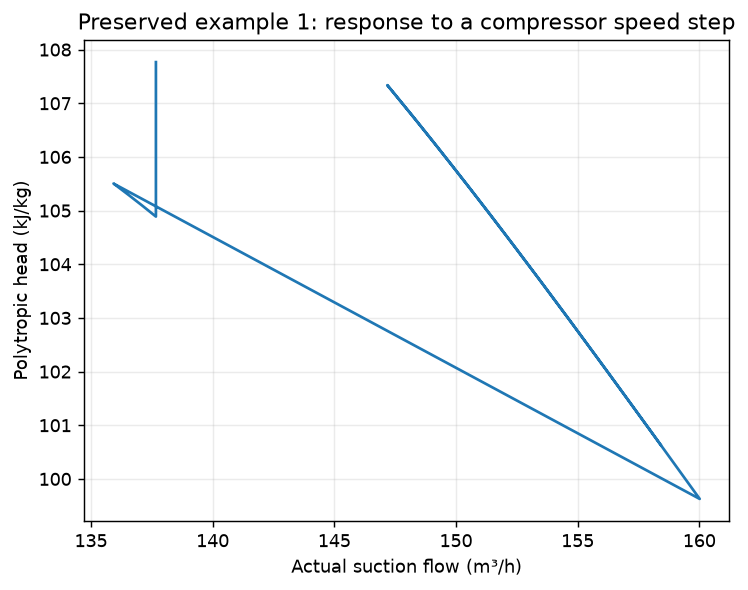

In [21]:
import neqsim
from neqsim import jneqsim
import matplotlib.pyplot as plt
testSystem2 = jneqsim.thermo.system.SystemSrkEos(273.15 + 25.0, 10.0)
testSystem2.addComponent('methane', 1.1)
testSystem2.addComponent('ethane', 0.1)
testSystem2.setMixingRule(2)
stream1 = jneqsim.process.equipment.stream.Stream('Stream1', testSystem2)
stream1.setFlowRate(5000.0, 'kg/hr')
stream1.setPressure(100.0, 'bara')
stream1.setTemperature(55.0, 'C')
valve1 = jneqsim.process.equipment.valve.ThrottlingValve('valve_1', stream1)
valve1.setOutletPressure(50.0)
valve1.setPercentValveOpening(50)
valve1.setCalculateSteadyState(False)
separator1 = jneqsim.process.equipment.separator.Separator('separator_1')
separator1.addStream(valve1.getOutletStream())
separator1.setCalculateSteadyState(False)
separator1.setSeparatorLength(3.0)
separator1.setInternalDiameter(0.8)
separator1.setLiquidLevel(0.0)
compressor1 = jneqsim.process.equipment.compressor.Compressor('comp1', separator1.getGasOutStream())
compressor1.setCalculateSteadyState(False)
compressor1.setOutletPressure(100.0)
separator2 = jneqsim.process.equipment.separator.Separator('separator_2')
separator2.addStream(compressor1.getOutletStream())
separator2.setCalculateSteadyState(False)
separator2.setSeparatorLength(3.0)
separator2.setInternalDiameter(0.8)
separator2.setLiquidLevel(0.0)
valve2 = jneqsim.process.equipment.valve.ThrottlingValve('valve_2', separator2.getGasOutStream())
valve2.setOutletPressure(50.0)
valve2.setPercentValveOpening(50)
valve2.setCalculateSteadyState(False)
p = jneqsim.process.processmodel.ProcessSystem()
p.add(stream1)
p.add(valve1)
p.add(separator1)
p.add(compressor1)
p.add(separator2)
p.add(valve2)
p.run()
compchartgenerator = jneqsim.process.equipment.compressor.CompressorChartGenerator(compressor1)
compressor1.setCompressorChart(compchartgenerator.generateCompressorChart('normal'))
compressor1.getCompressorChart().setUseCompressorChart(True)
p.run()
time = []
pressuresep1 = []
pressuresep2 = []
flow = []
head = []
p.setTimeStep(1.0)
for i in range(100):
    time.append(p.getTime())
    pressuresep1.append(separator1.getPressure())
    pressuresep2.append(separator2.getPressure())
    flow.append(compressor1.getInletStream().getFlowRate('m3/hr'))
    head.append(compressor1.getPolytropicFluidHead())
    p.runTransient()
compressor1.setSpeed(compressor1.getSpeed() + 200)
for i in range(500):
    time.append(p.getTime())
    pressuresep1.append(separator1.getPressure())
    pressuresep2.append(separator2.getPressure())
    flow.append(compressor1.getInletStream().getFlowRate('m3/hr'))
    head.append(compressor1.getPolytropicFluidHead())
    p.runTransient()
plt.plot(time, pressuresep1, label='suction separator')
plt.plot(time, pressuresep2, label='discharge separator')
plt.legend()
plt.title('Preserved example 1: response to a compressor speed step')
plt.xlabel('Time (s)')
plt.ylabel('Separator pressure (bara)')
plt.show()
plt.plot(flow, head)
plt.title('Preserved example 1: response to a compressor speed step')
plt.xlabel('Actual suction flow (m³/h)')
plt.ylabel('Polytropic head (kJ/kg)')
plt.show()


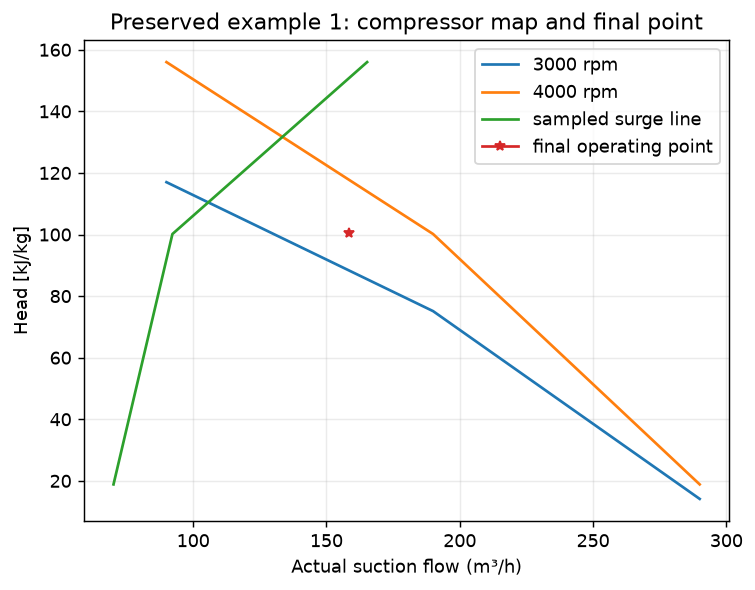

In [22]:
flow = []
head = []
head2 = []
surge = []
for i in range(90, 300, 100):
    flow.append(i)
    head.append(compressor1.getCompressorChart().getPolytropicHead(i, 3000))
    head2.append(compressor1.getCompressorChart().getPolytropicHead(i, 4000))
for i in head:
    surge.append(compressor1.getCompressorChart().getSurgeCurve().getSurgeFlow(i))
plt.plot(flow, head, label='3000 rpm')
plt.plot(flow, head2, label='4000 rpm')
plt.plot(surge, head2, label='sampled surge line')
plt.plot(
    compressor1.getInStream().getFlowRate("m3/hr"),
    compressor1.getPolytropicFluidHead(),
    marker="*",
    label="final operating point",
)
plt.legend()
plt.xlabel('Actual suction flow (m³/h)')
plt.ylabel('Head [kJ/kg]')
plt.title('Preserved example 1: compressor map and final point')
plt.grid(alpha=0.25)
plt.show()


### Preserved example 2 — discharge-pressure control through speed

A pressure transmitter on the discharge separator drives a PI speed controller. The example retains four figures for separator pressure, compressor flow, flow–head trajectory, and speed. It demonstrates that speed control and vessel inventory must be tuned as one dynamic system.

speed (rpm)                  3000.000000
feed flow (kg/h)              501.000000
compressor flow (kg/h)        501.000000
export flow (kg/h)            501.000000
suction pressure (bara)        50.000000
discharge pressure (bara)     101.743536
Name: preserved workflow diagnostics, dtype: float64

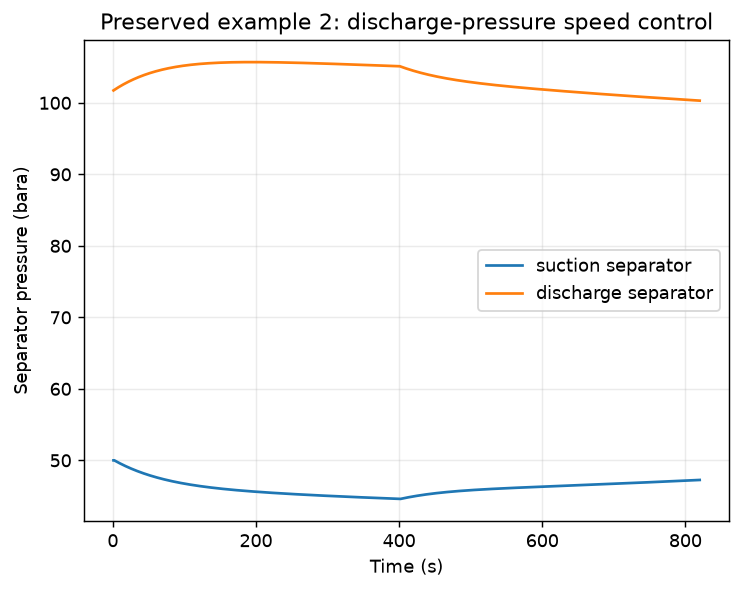

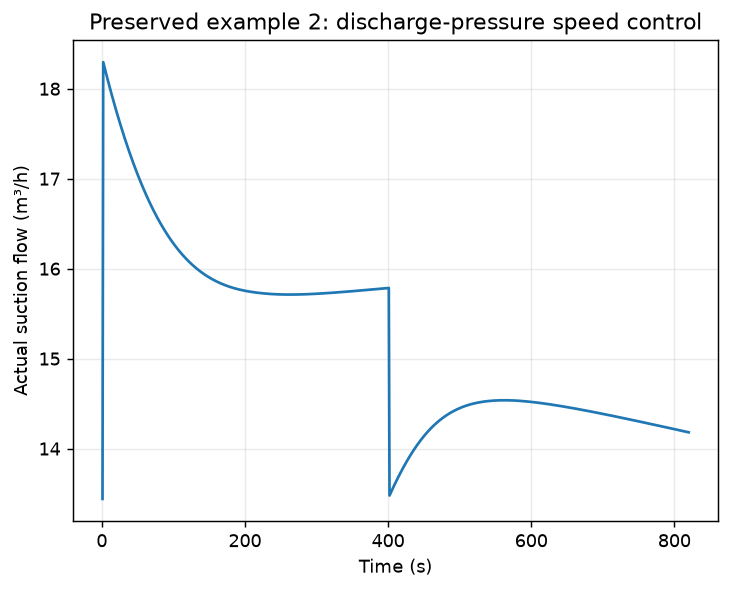

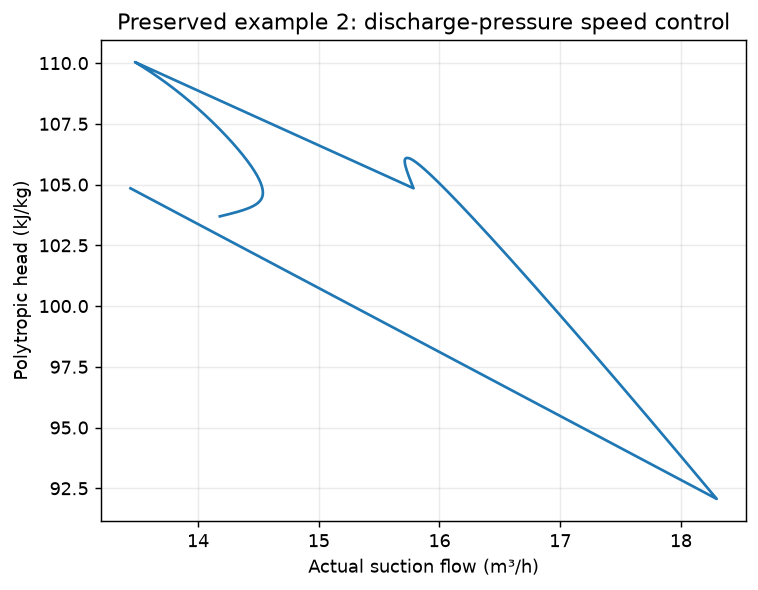

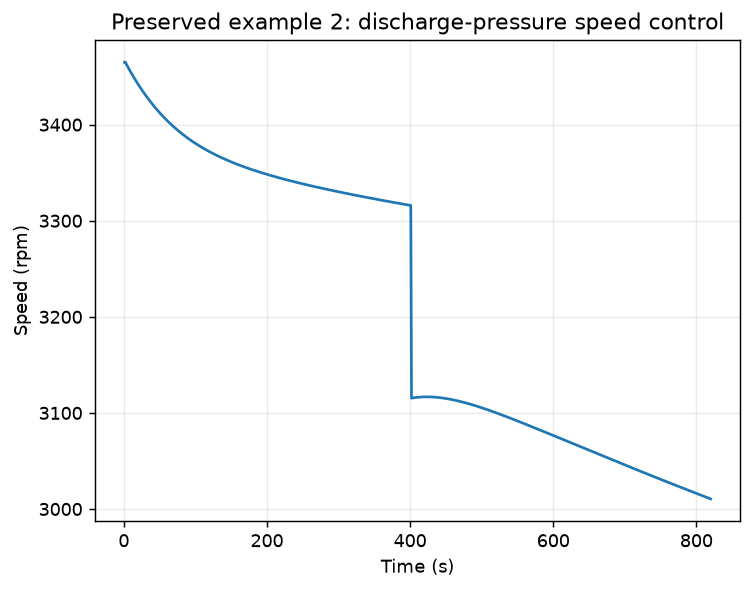

In [23]:
testSystem2 = jneqsim.thermo.system.SystemSrkEos(273.15 + 25.0, 10.0)
testSystem2.addComponent('methane', 1.1)
testSystem2.addComponent('ethane', 0.1)
testSystem2.setMixingRule(2)
stream1 = jneqsim.process.equipment.stream.Stream('Stream1', testSystem2)
stream1.setFlowRate(501.0, 'kg/hr')
stream1.setPressure(100.0, 'bara')
stream1.setTemperature(55.0, 'C')
valve1 = jneqsim.process.equipment.valve.ThrottlingValve('valve_1', stream1)
valve1.setOutletPressure(50.0)
valve1.setPercentValveOpening(10)
valve1.setCalculateSteadyState(False)
separator1 = jneqsim.process.equipment.separator.Separator('separator_1')
separator1.addStream(valve1.getOutletStream())
separator1.setCalculateSteadyState(False)
separator1.setSeparatorLength(3.0)
separator1.setInternalDiameter(0.8)
separator1.setLiquidLevel(0.0)
compressor1 = jneqsim.process.equipment.compressor.Compressor('comp1', separator1.getGasOutStream())
compressor1.setCalculateSteadyState(False)
compressor1.setOutletPressure(100.0)
separator2 = jneqsim.process.equipment.separator.Separator('separator_2')
separator2.addStream(compressor1.getOutletStream())
separator2.setCalculateSteadyState(False)
separator2.setSeparatorLength(3.0)
separator2.setInternalDiameter(0.8)
separator2.setLiquidLevel(0.0)
valve2 = jneqsim.process.equipment.valve.ThrottlingValve('valve_2', separator2.getGasOutStream())
valve2.setOutletPressure(50.0)
valve2.setPercentValveOpening(50)
valve2.setCalculateSteadyState(False)
separatorPressureTransmitter = (
    jneqsim.process.measurementdevice.PressureTransmitter(
        separator2.getGasOutStream()
    )
)
speedController = jneqsim.process.controllerdevice.ControllerDeviceBaseClass()
speedController.setReverseActing(True)
speedController.setTransmitter(separatorPressureTransmitter)
speedController.setControllerSetPoint(100.0)
speedController.setControllerParameters(0.2, 500.0, 0.0)
p = jneqsim.process.processmodel.ProcessSystem()
p.add(stream1)
p.add(valve1)
p.add(separator1)
p.add(compressor1)
p.add(separator2)
p.add(separatorPressureTransmitter)
p.add(valve2)
compressor1.setController(speedController)
p.run()
compchartgenerator = jneqsim.process.equipment.compressor.CompressorChartGenerator(compressor1)
compressor1.setCompressorChart(compchartgenerator.generateCompressorChart('normal'))
compressor1.getCompressorChart().setUseCompressorChart(True)
p.run()
display_legacy_diagnostics(compressor1, stream1, valve2)
p.setTimeStep(1.0)
p.runTransient()
time = []
pressuresep1 = []
pressuresep2 = []
flow = []
head = []
speed = []
compressor1.setSpeed(compressor1.getSpeed() + 500)
for i in range(400):
    time.append(p.getTime())
    pressuresep1.append(separator1.getPressure())
    pressuresep2.append(separator2.getPressure())
    flow.append(compressor1.getInletStream().getFlowRate('m3/hr'))
    head.append(compressor1.getPolytropicFluidHead())
    speed.append(compressor1.getSpeed())
    p.runTransient()
speedController.setControllerSetPoint(90.0)
for i in range(420):
    time.append(p.getTime())
    pressuresep1.append(separator1.getPressure())
    pressuresep2.append(separator2.getPressure())
    flow.append(compressor1.getInletStream().getFlowRate('m3/hr'))
    head.append(compressor1.getPolytropicFluidHead())
    speed.append(compressor1.getSpeed())
    p.runTransient()
plt.plot(time, pressuresep1, label='suction separator')
plt.plot(time, pressuresep2, label='discharge separator')
plt.legend()
plt.title('Preserved example 2: discharge-pressure speed control')
plt.xlabel('Time (s)')
plt.ylabel('Separator pressure (bara)')
plt.show()
plt.plot(time, flow)
plt.title('Preserved example 2: discharge-pressure speed control')
plt.ylabel('Actual suction flow (m³/h)')
plt.xlabel('Time (s)')
plt.show()
plt.plot(flow, head)
plt.title('Preserved example 2: discharge-pressure speed control')
plt.xlabel('Actual suction flow (m³/h)')
plt.ylabel('Polytropic head (kJ/kg)')
plt.show()
plt.plot(time, speed)
plt.title('Preserved example 2: discharge-pressure speed control')
plt.xlabel('Time (s)')
plt.ylabel('Speed (rpm)')
plt.show()


### Preserved example 3 — recycle-valve anti-surge control

A `CompressorMonitor`, splitter, recycle valve, `Recycle`, and PI controller protect the compressor after the inlet valve closes. Seven original figures are retained, covering pressures, total and recycle flow, valve position, flow, map trajectory, and distance to surge.

speed (rpm)                   3000.000000
feed flow (kg/h)               500.000000
compressor flow (kg/h)         505.050505
export flow (kg/h)             499.999995
suction pressure (bara)         50.000000
discharge pressure (bara)      101.748632
distance to surge (-)            1.500630
recycle flow (kg/h)              5.050505
recycle valve position (%)       2.000000
Name: preserved workflow diagnostics, dtype: float64

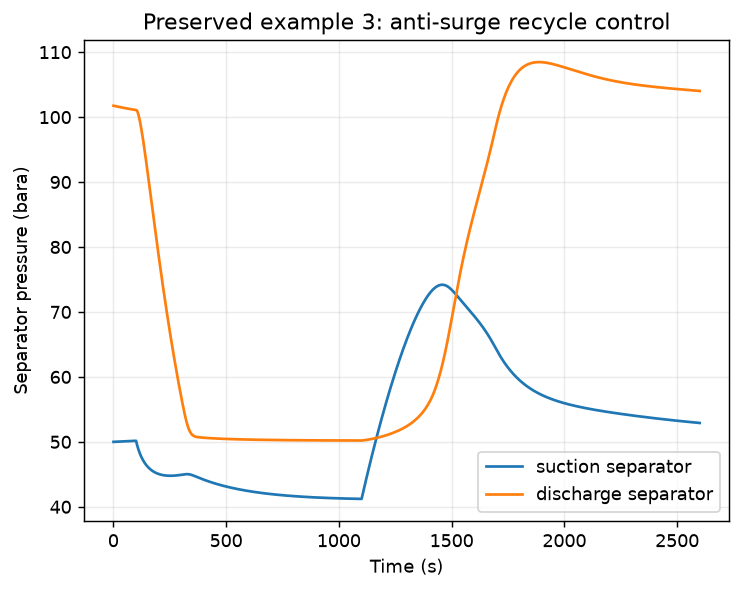

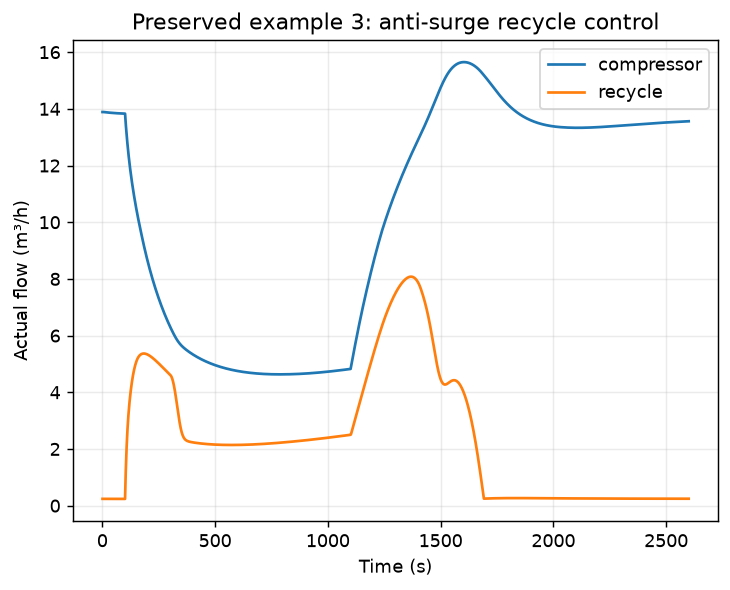

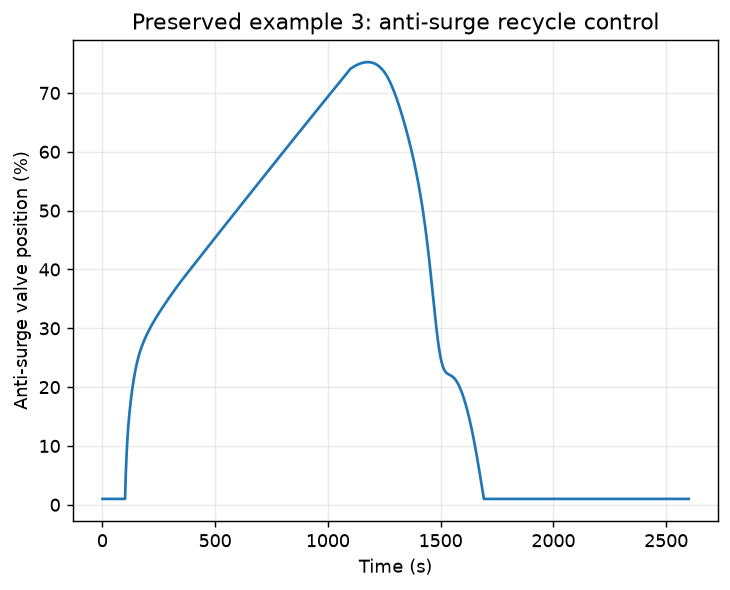

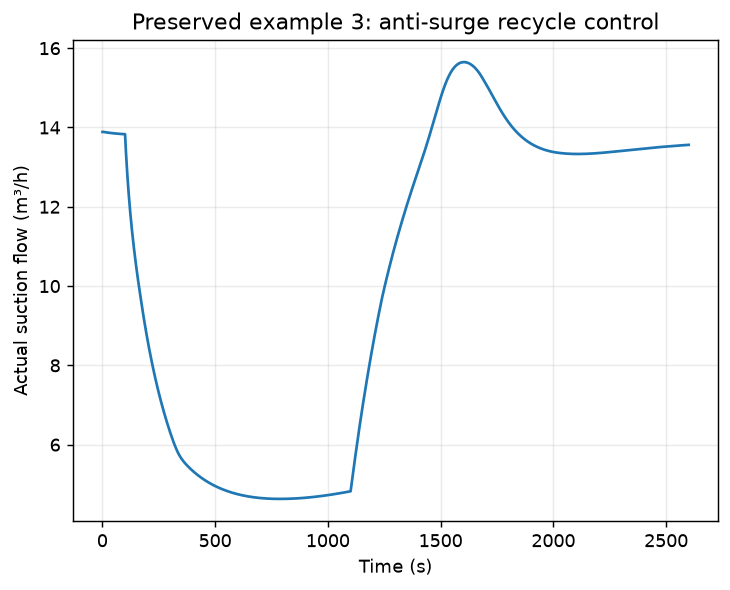

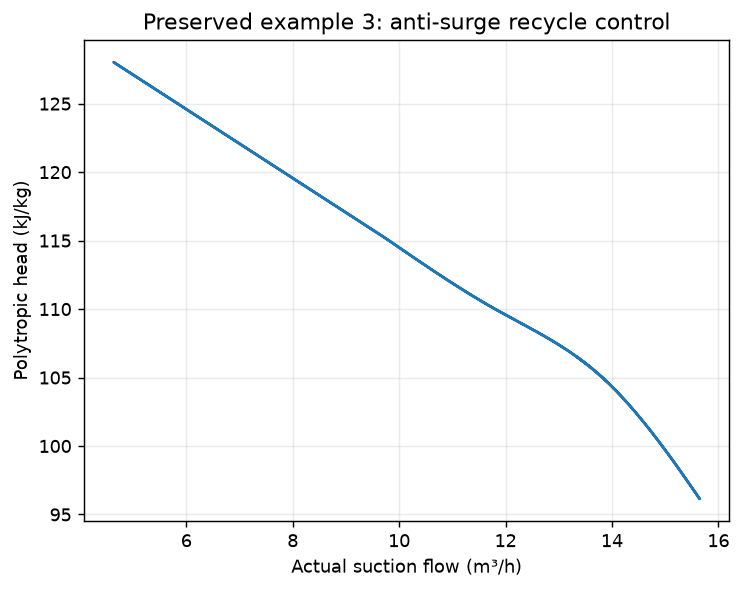

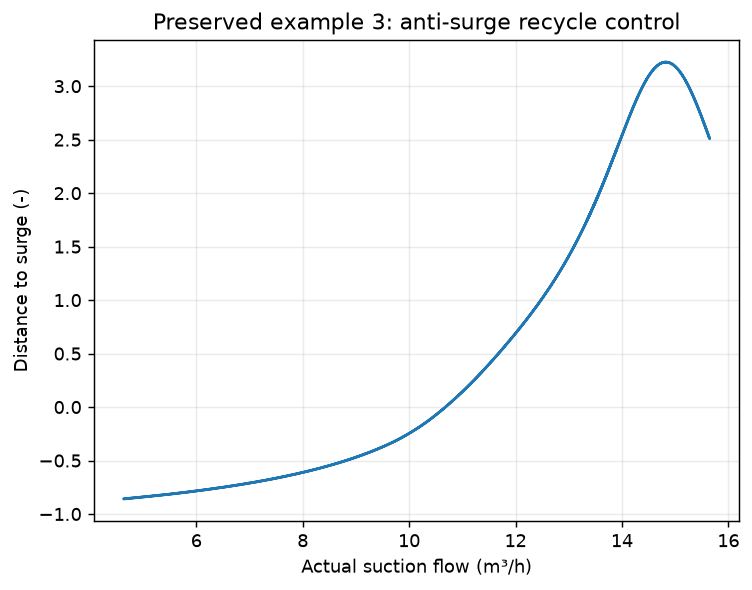

In [24]:
testSystem2 = jneqsim.thermo.system.SystemSrkEos(273.15 + 25.0, 10.0)
testSystem2.addComponent('methane', 1.1)
testSystem2.addComponent('ethane', 0.1)
testSystem2.setMixingRule(2)
stream1 = jneqsim.process.equipment.stream.Stream('Stream1', testSystem2)
stream1.setFlowRate(500.0, 'kg/hr')
stream1.setPressure(100.0, 'bara')
stream1.setTemperature(55.0, 'C')
valve1 = jneqsim.process.equipment.valve.ThrottlingValve('valve_1', stream1)
valve1.setOutletPressure(50.0)
valve1.setPercentValveOpening(50)
valve1.setCalculateSteadyState(False)
resycstream = stream1.clone()
resycstream.setName('recs')
resycstream.setFlowRate(0.01, 'kg/hr')
separator1 = jneqsim.process.equipment.separator.Separator('separator_1')
separator1.addStream(valve1.getOutletStream())
separator1.addStream(resycstream)
separator1.setCalculateSteadyState(False)
separator1.setSeparatorLength(3.0)
separator1.setInternalDiameter(0.8)
separator1.setLiquidLevel(0.0)
compressor1 = jneqsim.process.equipment.compressor.Compressor(
    "compressor 1",
    separator1.getGasOutStream(),
)
compressor1.setCalculateSteadyState(False)
compressor1.setOutletPressure(100.0)
surgemonitor = jneqsim.process.measurementdevice.CompressorMonitor(compressor1)
surgemonitor.setMaximumValue(5.0)
surgemonitor.setMinimumValue(-5.0)
aftercooler = jneqsim.process.equipment.heatexchanger.Cooler(
    "after cooler",
    compressor1.getOutletStream(),
)
aftercooler.setOutTemperature(30.0, 'C')
aftercooler.setCalculateSteadyState(False)
separator2 = jneqsim.process.equipment.separator.Separator('separator_2')
separator2.addStream(aftercooler.getOutletStream())
separator2.setCalculateSteadyState(False)
separator2.setSeparatorLength(3.0)
separator2.setInternalDiameter(0.5)
separator2.setLiquidLevel(0.0)
gasfromsep2 = jneqsim.process.equipment.stream.Stream('gas from sep', separator2.getGasOutStream())
splitter = jneqsim.process.equipment.splitter.Splitter('splitter1', gasfromsep2)
splitter.setSplitFactors([0.99, 0.01])
splitter.setCalculateSteadyState(False)
recycleValve = jneqsim.process.equipment.valve.ThrottlingValve(
    "anti surge valve",
    splitter.getSplitStream(1),
)
recycleValve.setPressure(50.0)
recycleValve.setCalculateSteadyState(False)
recycleValve.setMinimumValveOpening(1.0)
recycleValve.setPercentValveOpening(2)
pressureset = jneqsim.process.equipment.util.SetPoint(
    "recycle pressure setpoint",
    recycleValve,
    "pressure",
    separator1.getGasOutStream(),
)
recycle = jneqsim.process.equipment.util.Recycle('resycle 1')
recycle.addStream(recycleValve.getOutletStream())
recycle.setOutletStream(resycstream)
recycle.setTolerance(0.0001)
valve2 = jneqsim.process.equipment.valve.ThrottlingValve('valve_2', splitter.getSplitStream(0))
valve2.setOutletPressure(50.0)
valve2.setPercentValveOpening(50)
valve2.setCalculateSteadyState(False)
valve2.setMinimumValveOpening(1.0)
surgeController = jneqsim.process.controllerdevice.ControllerDeviceBaseClass()
surgeController.setReverseActing(True)
surgeController.setTransmitter(surgemonitor)
surgeController.setControllerSetPoint(0.1)
surgeController.setControllerParameters(1.0, 200.0, 0.0)
surgeController.setActive(True)
p = jneqsim.process.processmodel.ProcessSystem()
p.add(stream1)
p.add(resycstream)
p.add(valve1)
p.add(separator1)
p.add(compressor1)
p.add(surgemonitor)
p.add(aftercooler)
p.add(separator2)
p.add(gasfromsep2)
p.add(splitter)
p.add(recycleValve)
p.add(recycle)
p.add(valve2)
recycleValve.setController(surgeController)
p.run()
recycleValve.setCv(valve2.getCv())
compchartgenerator = jneqsim.process.equipment.compressor.CompressorChartGenerator(compressor1)
compressor1.setCompressorChart(compchartgenerator.generateCompressorChart('normal'))
compressor1.getCompressorChart().setUseCompressorChart(True)
p.run()
display_legacy_diagnostics(compressor1, stream1, valve2, surgemonitor, recycleValve)
p.setTimeStep(1.0)
time = []
pressuresep1 = []
pressuresep2 = []
flow = []
antisrugevalveposition = []
antisrugeflow = []
head = []
distancetosurge = []
p.runTransient()
for i in range(100):
    time.append(p.getTime())
    pressuresep1.append(separator1.getPressure())
    pressuresep2.append(separator2.getPressure())
    flow.append(compressor1.getInletStream().getFlowRate('m3/hr'))
    antisrugevalveposition.append(recycleValve.getPercentValveOpening())
    antisrugeflow.append(recycleValve.getOutletStream().getFlowRate('m3/hr'))
    head.append(compressor1.getPolytropicFluidHead())
    distancetosurge.append(surgemonitor.getMeasuredValue('distance to surge'))
    p.runTransient()
valve1.setPercentValveOpening(5.0)
for i in range(1000):
    time.append(p.getTime())
    pressuresep1.append(separator1.getPressure())
    pressuresep2.append(separator2.getPressure())
    flow.append(compressor1.getInletStream().getFlowRate('m3/hr'))
    antisrugevalveposition.append(recycleValve.getPercentValveOpening())
    antisrugeflow.append(recycleValve.getOutletStream().getFlowRate('m3/hr'))
    head.append(compressor1.getPolytropicFluidHead())
    distancetosurge.append(surgemonitor.getMeasuredValue('distance to surge'))
    p.runTransient()
valve1.setPercentValveOpening(50.0)
for i in range(1500):
    time.append(p.getTime())
    pressuresep1.append(separator1.getPressure())
    pressuresep2.append(separator2.getPressure())
    flow.append(compressor1.getInletStream().getFlowRate('m3/hr'))
    antisrugevalveposition.append(recycleValve.getPercentValveOpening())
    antisrugeflow.append(recycleValve.getOutletStream().getFlowRate('m3/hr'))
    head.append(compressor1.getPolytropicFluidHead())
    distancetosurge.append(surgemonitor.getMeasuredValue('distance to surge'))
    p.runTransient()
plt.plot(time, pressuresep1, label='suction separator')
plt.plot(time, pressuresep2, label='discharge separator')
plt.legend()
plt.title('Preserved example 3: anti-surge recycle control')
plt.xlabel('Time (s)')
plt.ylabel('Separator pressure (bara)')
plt.show()
plt.plot(time, flow, label='compressor')
plt.plot(time, antisrugeflow, label='recycle')
plt.legend()
plt.title('Preserved example 3: anti-surge recycle control')
plt.xlabel('Time (s)')
plt.ylabel('Actual flow (m³/h)')
plt.show()
plt.plot(time, antisrugevalveposition)
plt.title('Preserved example 3: anti-surge recycle control')
plt.xlabel('Time (s)')
plt.ylabel('Anti-surge valve position (%)')
plt.show()
plt.plot(time, flow)
plt.title('Preserved example 3: anti-surge recycle control')
plt.ylabel('Actual suction flow (m³/h)')
plt.xlabel('Time (s)')
plt.show()
plt.plot(flow, head)
plt.title('Preserved example 3: anti-surge recycle control')
plt.xlabel('Actual suction flow (m³/h)')
plt.ylabel('Polytropic head (kJ/kg)')
plt.show()
plt.plot(flow, distancetosurge)
plt.title('Preserved example 3: anti-surge recycle control')
plt.xlabel('Actual suction flow (m³/h)')
plt.ylabel('Distance to surge (-)')
plt.show()


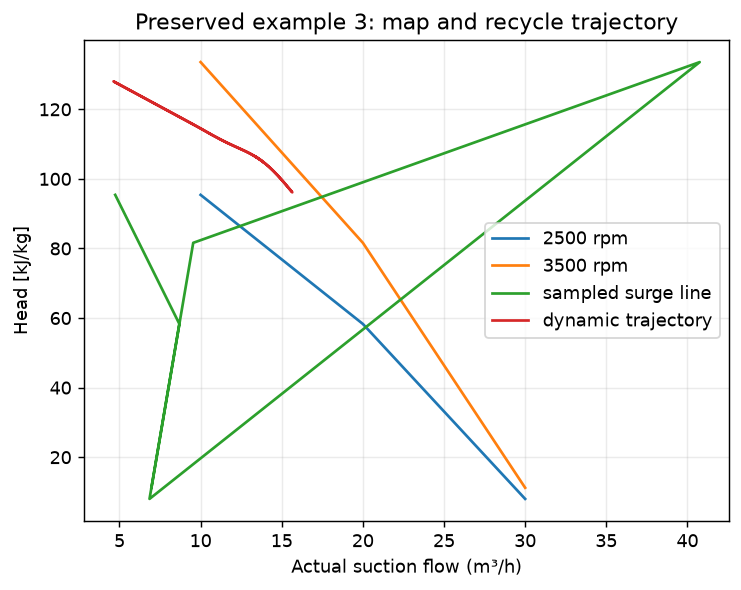

In [25]:
import numpy as np
flow1 = []
head1 = []
head2 = []
surge = []
for i in range(10, 40, 10):
    flow1.append(i)
    head1.append(compressor1.getCompressorChart().getPolytropicHead(i, 2500))
    head2.append(compressor1.getCompressorChart().getPolytropicHead(i, 3500))
sorted_head_values = np.sort(np.array(head1 + head2))
for i in head1 + head2:
    surge.append(compressor1.getCompressorChart().getSurgeCurve().getSurgeFlow(i))
plt.plot(flow1, head1, label='2500 rpm')
plt.plot(flow1, head2, label='3500 rpm')
plt.plot(surge, head1 + head2, label='sampled surge line')
plt.plot(flow, head, label='dynamic trajectory')
plt.legend()
plt.xlabel('Actual suction flow (m³/h)')
plt.ylabel('Head [kJ/kg]')
plt.title('Preserved example 3: map and recycle trajectory')
plt.grid(alpha=0.25)
plt.show()


### Preserved example 4 — combined pressure and anti-surge control

The discharge-pressure speed loop and recycle-valve surge loop operate together. Eight original figures are retained. This interaction matters because both controllers change compressor flow and head, so independent tuning can create conflict or oscillation.

speed (rpm)                   3000.000000
feed flow (kg/h)               500.000000
compressor flow (kg/h)         505.050505
export flow (kg/h)             499.999995
suction pressure (bara)         50.000000
discharge pressure (bara)      101.748632
distance to surge (-)            1.500630
recycle flow (kg/h)              5.050505
recycle valve position (%)       2.000000
Name: preserved workflow diagnostics, dtype: float64

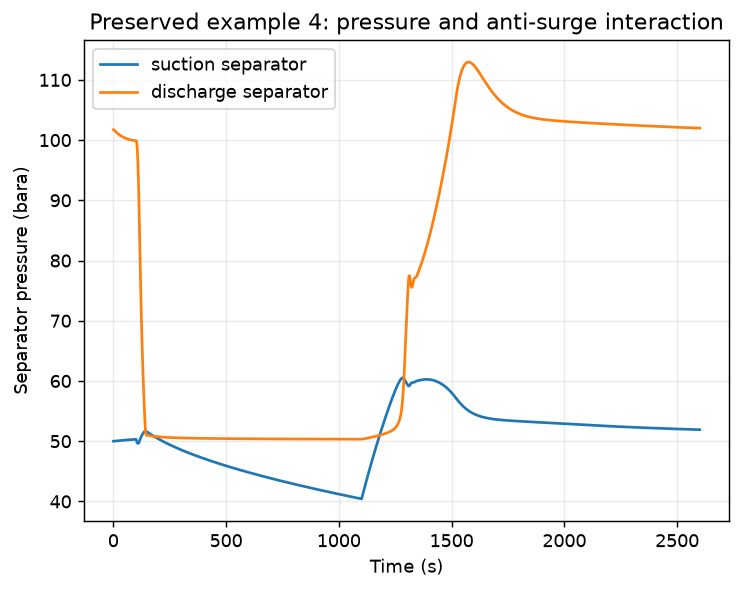

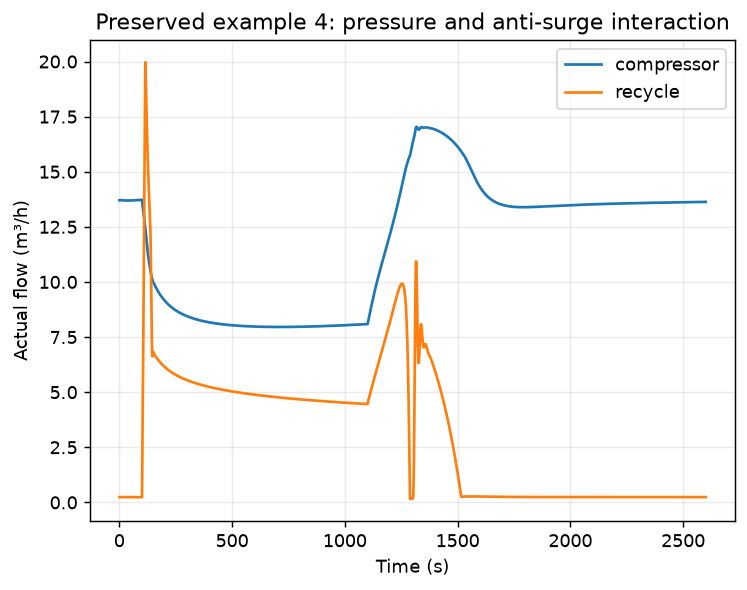

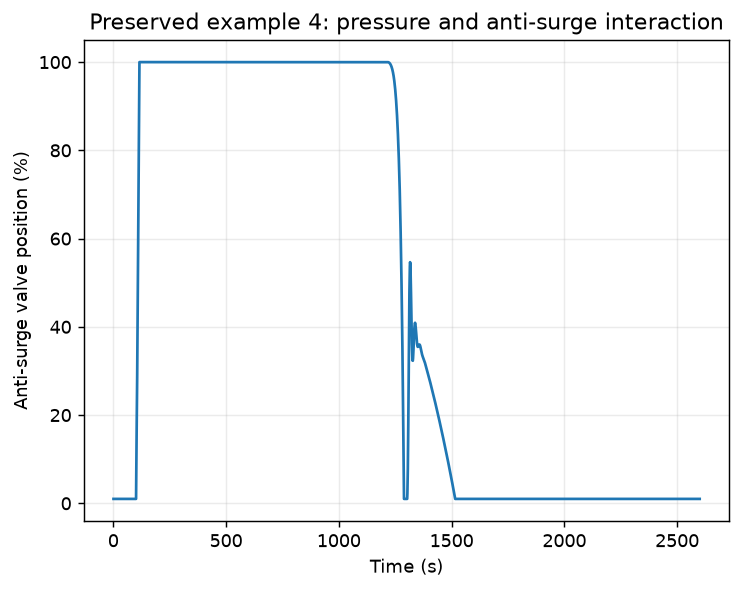

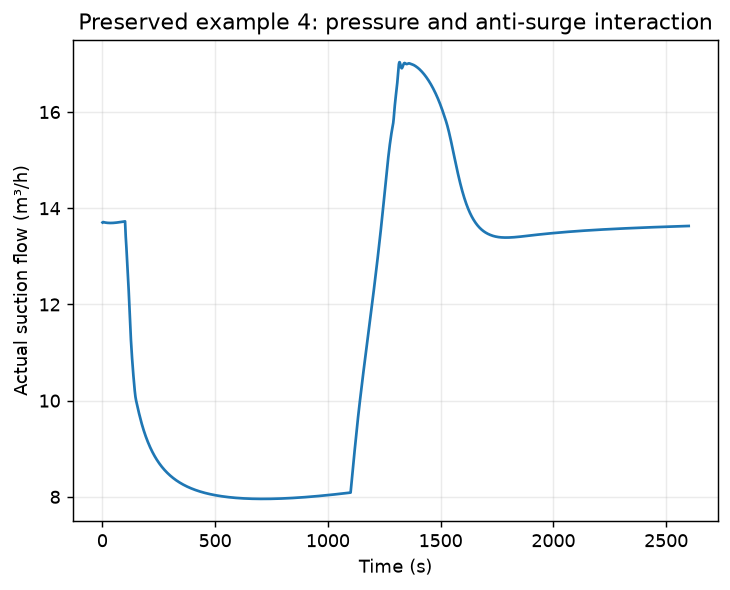

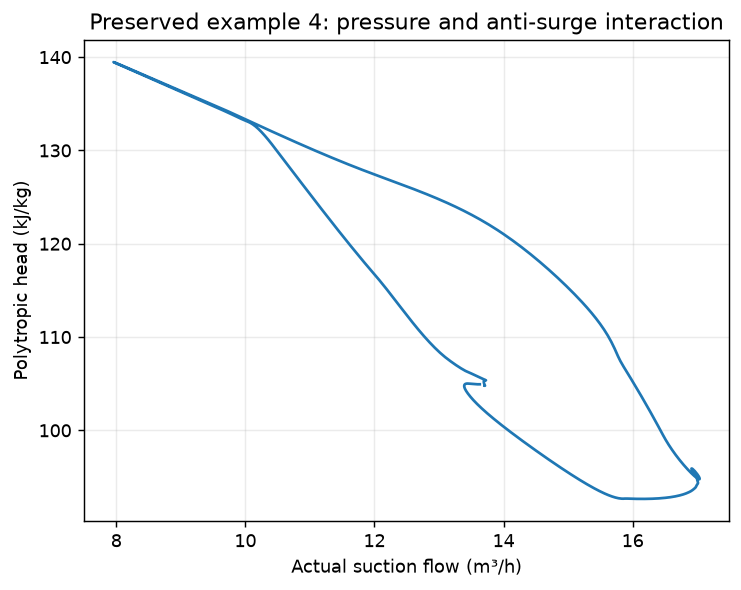

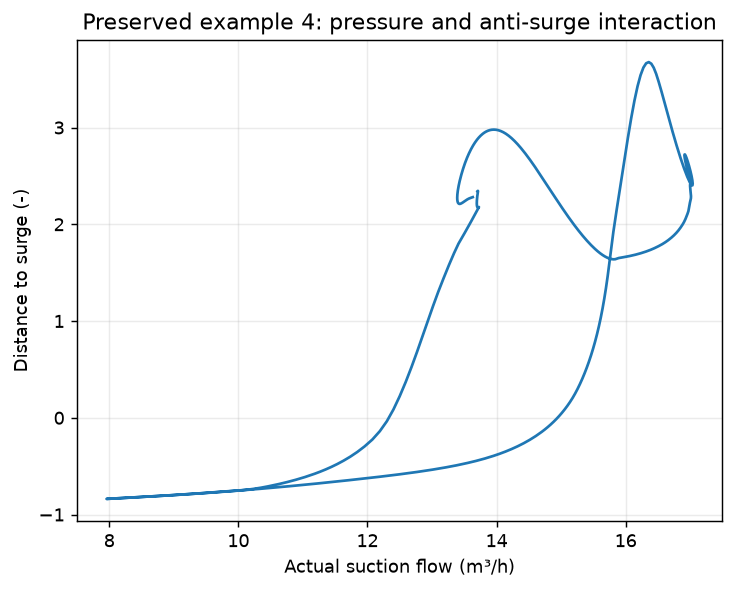

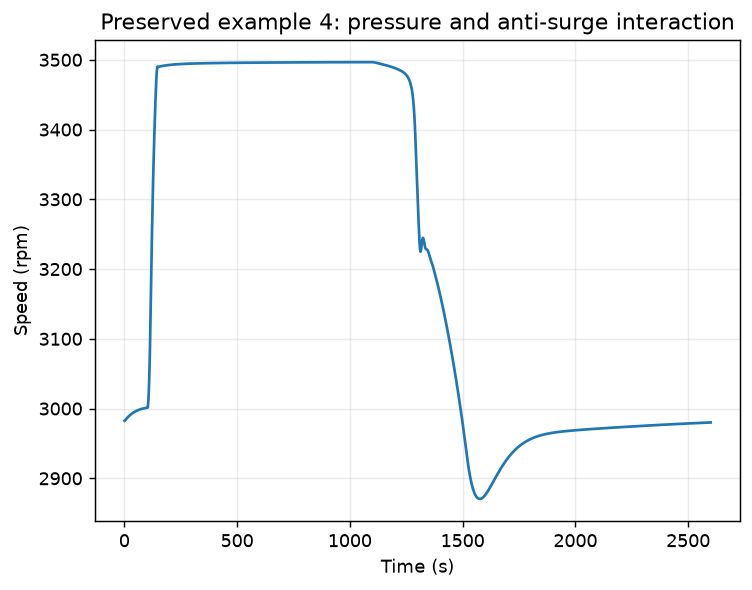

In [26]:
testSystem2 = jneqsim.thermo.system.SystemSrkEos(273.15 + 25.0, 10.0)
testSystem2.addComponent('methane', 1.1)
testSystem2.addComponent('ethane', 0.1)
testSystem2.setMixingRule(2)
stream1 = jneqsim.process.equipment.stream.Stream('Stream1', testSystem2)
stream1.setFlowRate(500.0, 'kg/hr')
stream1.setPressure(100.0, 'bara')
stream1.setTemperature(55.0, 'C')
valve1 = jneqsim.process.equipment.valve.ThrottlingValve('valve_1', stream1)
valve1.setOutletPressure(50.0)
valve1.setPercentValveOpening(50)
valve1.setCalculateSteadyState(False)
resycstream = stream1.clone()
resycstream.setName('rec1')
resycstream.setFlowRate(0.01, 'kg/hr')
separator1 = jneqsim.process.equipment.separator.Separator('separator_1')
separator1.addStream(valve1.getOutletStream())
separator1.addStream(resycstream)
separator1.setCalculateSteadyState(False)
separator1.setSeparatorLength(3.0)
separator1.setInternalDiameter(0.8)
separator1.setLiquidLevel(0.0)
compressor1 = jneqsim.process.equipment.compressor.Compressor('comp1', separator1.getGasOutStream())
compressor1.setCalculateSteadyState(False)
compressor1.setOutletPressure(100.0)
surgemonitor = jneqsim.process.measurementdevice.CompressorMonitor(compressor1)
surgemonitor.setMaximumValue(5.0)
surgemonitor.setMinimumValue(-5.0)
aftercooler = jneqsim.process.equipment.heatexchanger.Cooler(
    "after cooler",
    compressor1.getOutletStream(),
)
aftercooler.setOutTemperature(30.0, 'C')
aftercooler.setCalculateSteadyState(False)
separator2 = jneqsim.process.equipment.separator.Separator('separator_2')
separator2.addStream(aftercooler.getOutletStream())
separator2.setCalculateSteadyState(False)
separator2.setSeparatorLength(1.0)
separator2.setInternalDiameter(0.5)
separator2.setLiquidLevel(0.0)
gasfromsep2 = jneqsim.process.equipment.stream.Stream('gas from sep', separator2.getGasOutStream())
splitter = jneqsim.process.equipment.splitter.Splitter('splitter1', gasfromsep2)
splitter.setSplitFactors([0.99, 0.01])
splitter.setCalculateSteadyState(False)
recycleValve = jneqsim.process.equipment.valve.ThrottlingValve(
    "anti surge valve",
    splitter.getSplitStream(1),
)
recycleValve.setPressure(50.0)
recycleValve.setCalculateSteadyState(False)
recycleValve.setMinimumValveOpening(1.0)
recycleValve.setPercentValveOpening(2)
pressureset = jneqsim.process.equipment.util.SetPoint(
    "recycle pressure setpoint",
    recycleValve,
    "pressure",
    separator1.getGasOutStream(),
)
recycle = jneqsim.process.equipment.util.Recycle('resycle 1')
recycle.addStream(recycleValve.getOutletStream())
recycle.setOutletStream(resycstream)
recycle.setTolerance(0.0001)
valve2 = jneqsim.process.equipment.valve.ThrottlingValve('valve_2', splitter.getSplitStream(0))
valve2.setOutletPressure(50.0)
valve2.setPercentValveOpening(50)
valve2.setCalculateSteadyState(False)
valve2.setMinimumValveOpening(1.0)
separatorPressureTransmitter = (
    jneqsim.process.measurementdevice.PressureTransmitter(
        separator2.getGasOutStream()
    )
)
speedController = jneqsim.process.controllerdevice.ControllerDeviceBaseClass()
speedController.setReverseActing(True)
speedController.setTransmitter(separatorPressureTransmitter)
speedController.setControllerSetPoint(100.0)
speedController.setControllerParameters(0.1, 0.0, 0.0)
speedController.setActive(True)
surgeController = jneqsim.process.controllerdevice.ControllerDeviceBaseClass()
surgeController.setReverseActing(True)
surgeController.setTransmitter(surgemonitor)
surgeController.setControllerSetPoint(0.2)
surgeController.setControllerParameters(5.0, 200.0, 0.0)
surgeController.setActive(True)
p = jneqsim.process.processmodel.ProcessSystem()
p.add(stream1)
p.add(resycstream)
p.add(valve1)
p.add(separator1)
p.add(compressor1)
p.add(surgemonitor)
p.add(aftercooler)
p.add(separator2)
p.add(gasfromsep2)
p.add(splitter)
p.add(recycleValve)
p.add(recycle)
p.add(valve2)
recycleValve.setController(surgeController)
p.add(separatorPressureTransmitter)
compressor1.setController(speedController)
p.run()
recycleValve.setCv(valve2.getCv())
compchartgenerator = jneqsim.process.equipment.compressor.CompressorChartGenerator(compressor1)
compressor1.setCompressorChart(compchartgenerator.generateCompressorChart('normal'))
compressor1.getCompressorChart().setUseCompressorChart(True)
p.run()
display_legacy_diagnostics(compressor1, stream1, valve2, surgemonitor, recycleValve)
p.setTimeStep(1.0)
time = []
pressuresep1 = []
pressuresep2 = []
flow = []
antisrugevalveposition = []
antisrugeflow = []
head = []
distancetosurge = []
speed = []
p.runTransient()
for i in range(100):
    time.append(p.getTime())
    pressuresep1.append(separator1.getPressure())
    pressuresep2.append(separator2.getPressure())
    flow.append(compressor1.getInletStream().getFlowRate('m3/hr'))
    antisrugevalveposition.append(recycleValve.getPercentValveOpening())
    antisrugeflow.append(recycleValve.getOutletStream().getFlowRate('m3/hr'))
    head.append(compressor1.getPolytropicFluidHead())
    distancetosurge.append(surgemonitor.getMeasuredValue('distance to surge'))
    speed.append(compressor1.getSpeed())
    p.runTransient()
valve1.setPercentValveOpening(5.0)
for i in range(1000):
    time.append(p.getTime())
    pressuresep1.append(separator1.getPressure())
    pressuresep2.append(separator2.getPressure())
    flow.append(compressor1.getInletStream().getFlowRate('m3/hr'))
    antisrugevalveposition.append(recycleValve.getPercentValveOpening())
    antisrugeflow.append(recycleValve.getOutletStream().getFlowRate('m3/hr'))
    head.append(compressor1.getPolytropicFluidHead())
    distancetosurge.append(surgemonitor.getMeasuredValue('distance to surge'))
    speed.append(compressor1.getSpeed())
    p.runTransient()
valve1.setPercentValveOpening(50.0)
for i in range(1500):
    time.append(p.getTime())
    pressuresep1.append(separator1.getPressure())
    pressuresep2.append(separator2.getPressure())
    flow.append(compressor1.getInletStream().getFlowRate('m3/hr'))
    antisrugevalveposition.append(recycleValve.getPercentValveOpening())
    antisrugeflow.append(recycleValve.getOutletStream().getFlowRate('m3/hr'))
    head.append(compressor1.getPolytropicFluidHead())
    distancetosurge.append(surgemonitor.getMeasuredValue('distance to surge'))
    speed.append(compressor1.getSpeed())
    p.runTransient()
plt.plot(time, pressuresep1, label='suction separator')
plt.plot(time, pressuresep2, label='discharge separator')
plt.legend()
plt.title('Preserved example 4: pressure and anti-surge interaction')
plt.xlabel('Time (s)')
plt.ylabel('Separator pressure (bara)')
plt.show()
plt.plot(time, flow, label='compressor')
plt.plot(time, antisrugeflow, label='recycle')
plt.legend()
plt.title('Preserved example 4: pressure and anti-surge interaction')
plt.xlabel('Time (s)')
plt.ylabel('Actual flow (m³/h)')
plt.show()
plt.plot(time, antisrugevalveposition)
plt.title('Preserved example 4: pressure and anti-surge interaction')
plt.xlabel('Time (s)')
plt.ylabel('Anti-surge valve position (%)')
plt.show()
plt.plot(time, flow)
plt.title('Preserved example 4: pressure and anti-surge interaction')
plt.ylabel('Actual suction flow (m³/h)')
plt.xlabel('Time (s)')
plt.show()
plt.plot(flow, head)
plt.title('Preserved example 4: pressure and anti-surge interaction')
plt.xlabel('Actual suction flow (m³/h)')
plt.ylabel('Polytropic head (kJ/kg)')
plt.show()
plt.plot(flow, distancetosurge)
plt.title('Preserved example 4: pressure and anti-surge interaction')
plt.xlabel('Actual suction flow (m³/h)')
plt.ylabel('Distance to surge (-)')
plt.show()
plt.plot(time, speed)
plt.title('Preserved example 4: pressure and anti-surge interaction')
plt.ylabel('Speed (rpm)')
plt.xlabel('Time (s)')
plt.show()


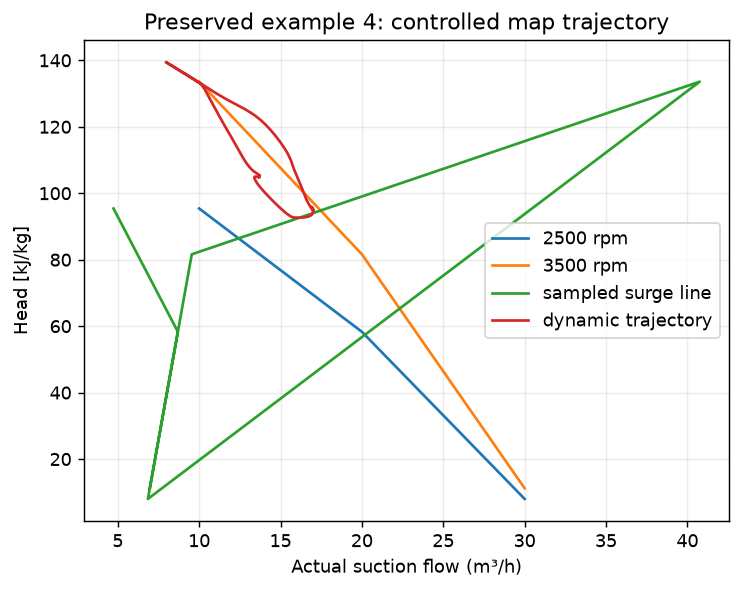

In [27]:
import numpy as np
flow1 = []
head1 = []
head2 = []
surge = []
for i in range(10, 40, 10):
    flow1.append(i)
    head1.append(compressor1.getCompressorChart().getPolytropicHead(i, 2500))
    head2.append(compressor1.getCompressorChart().getPolytropicHead(i, 3500))
sorted_head_values = np.sort(np.array(head1 + head2))
for i in head1 + head2:
    surge.append(compressor1.getCompressorChart().getSurgeCurve().getSurgeFlow(i))
plt.plot(flow1, head1, label='2500 rpm')
plt.plot(flow1, head2, label='3500 rpm')
plt.plot(surge, head1 + head2, label='sampled surge line')
plt.plot(flow, head, label='dynamic trajectory')
plt.legend()
plt.xlabel('Actual suction flow (m³/h)')
plt.ylabel('Head [kJ/kg]')
plt.title('Preserved example 4: controlled map trajectory')
plt.grid(alpha=0.25)
plt.show()


### Preserved example 5 — depressurization and startup

The connected process is first depressurized with the controllers inactive, then restarted with pressure and surge control restored. Eight original figures are retained for the pressure, flow, recycle, valve, map, surge-distance, and speed responses. This is a screening workflow; real startup requires permissives, trips, coast-down, valve stroking, and vendor limits.

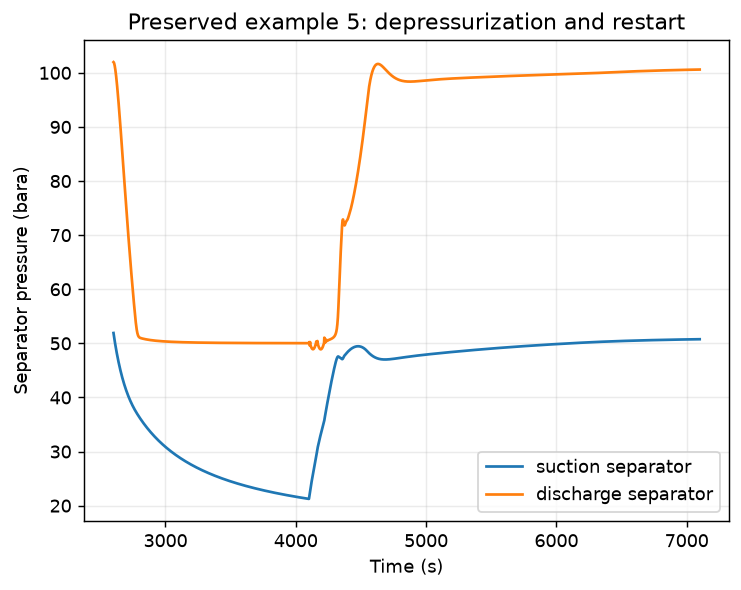

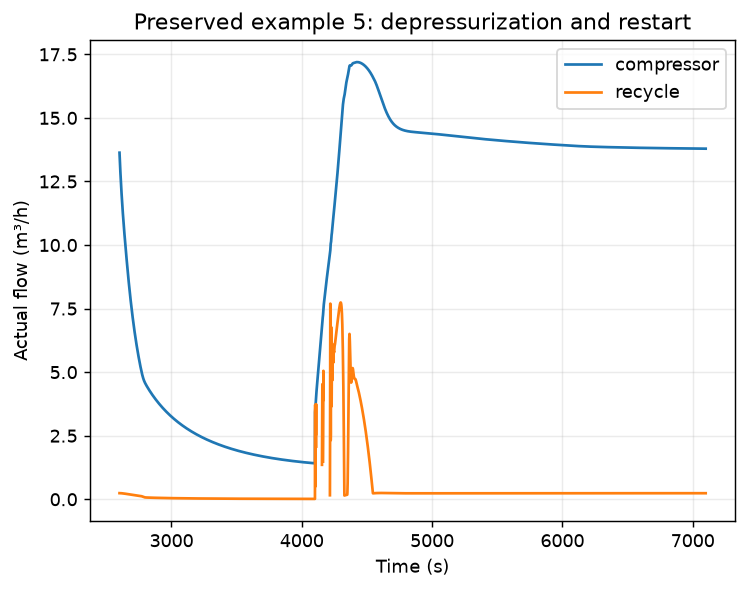

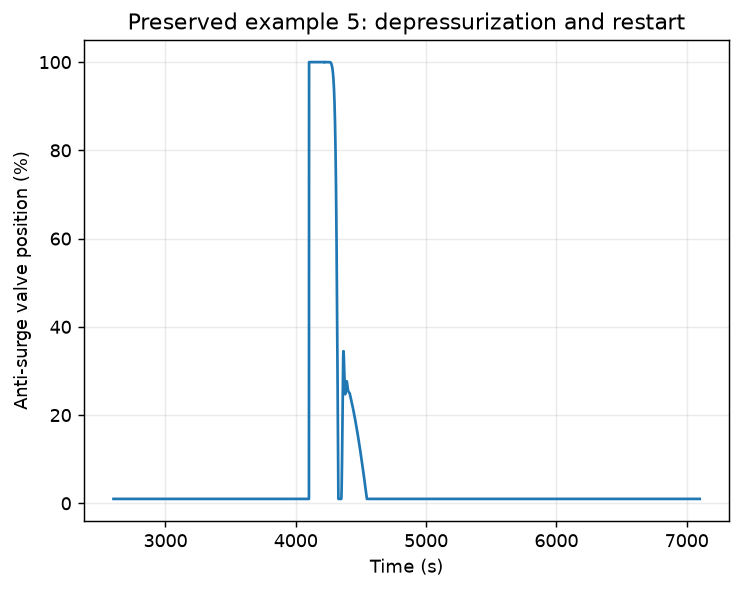

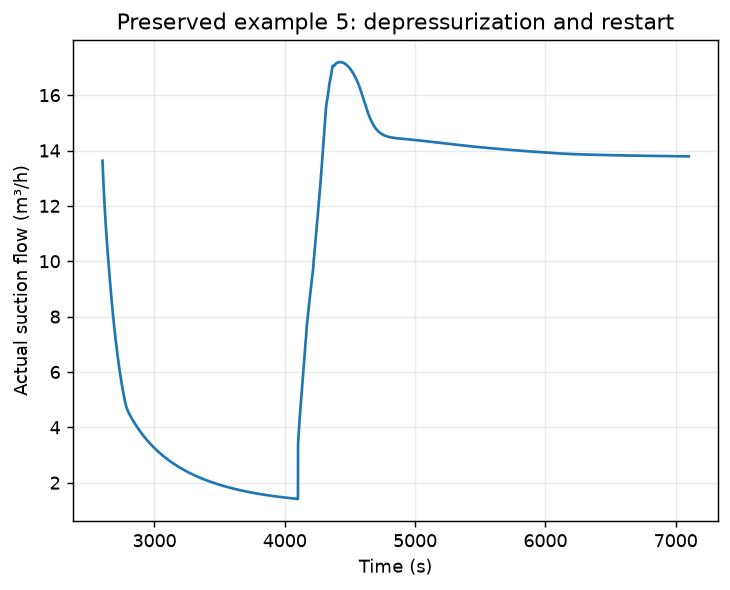

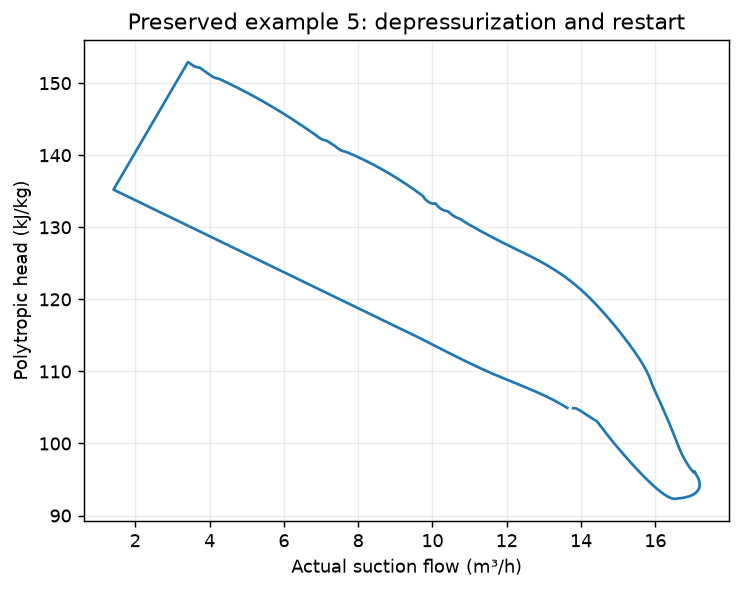

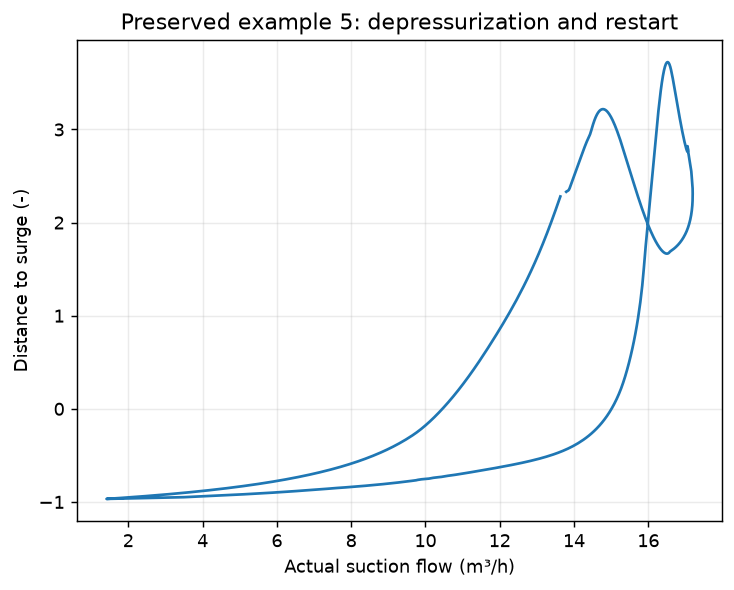

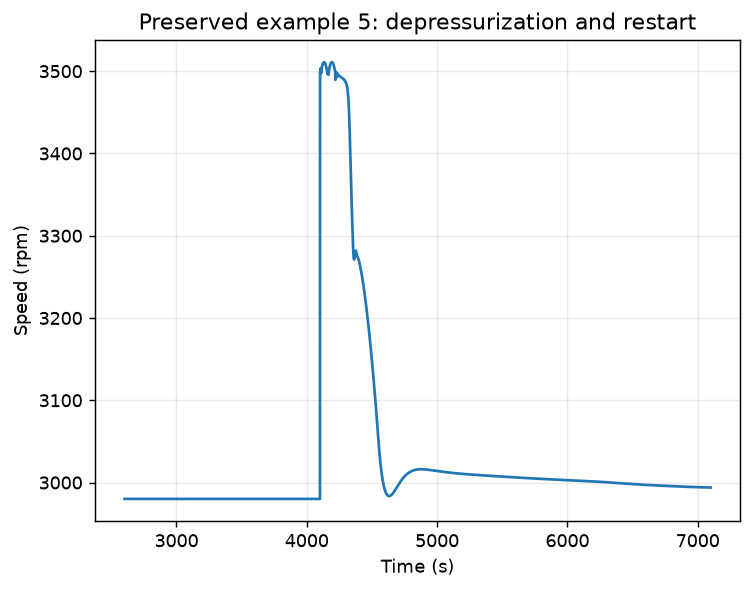

In [28]:
time = []
pressuresep1 = []
pressuresep2 = []
flow = []
antisrugevalveposition = []
antisrugeflow = []
head = []
distancetosurge = []
speed = []
valve1.setPercentValveOpening(1.0)
valve2.setPercentValveOpening(50.0)
recycleValve.setPercentValveOpening(1.0)
speedController.setActive(False)
surgeController.setActive(False)
for i in range(1500):
    time.append(p.getTime())
    pressuresep1.append(separator1.getPressure())
    pressuresep2.append(separator2.getPressure())
    flow.append(compressor1.getInletStream().getFlowRate('m3/hr'))
    antisrugevalveposition.append(recycleValve.getPercentValveOpening())
    antisrugeflow.append(recycleValve.getOutletStream().getFlowRate('m3/hr'))
    head.append(compressor1.getPolytropicFluidHead())
    distancetosurge.append(surgemonitor.getMeasuredValue('distance to surge'))
    speed.append(compressor1.getSpeed())
    p.runTransient()
valve2.setOutletPressure(50.0)
valve1.setPercentValveOpening(50.0)
speedController.setActive(True)
surgeController.setActive(True)
for i in range(3000):
    time.append(p.getTime())
    pressuresep1.append(separator1.getPressure())
    pressuresep2.append(separator2.getPressure())
    flow.append(compressor1.getInletStream().getFlowRate('m3/hr'))
    antisrugevalveposition.append(recycleValve.getPercentValveOpening())
    antisrugeflow.append(recycleValve.getOutletStream().getFlowRate('m3/hr'))
    head.append(compressor1.getPolytropicFluidHead())
    distancetosurge.append(surgemonitor.getMeasuredValue('distance to surge'))
    speed.append(compressor1.getSpeed())
    p.runTransient()
plt.plot(time, pressuresep1, label='suction separator')
plt.plot(time, pressuresep2, label='discharge separator')
plt.legend()
plt.title('Preserved example 5: depressurization and restart')
plt.xlabel('Time (s)')
plt.ylabel('Separator pressure (bara)')
plt.show()
plt.plot(time, flow, label='compressor')
plt.plot(time, antisrugeflow, label='recycle')
plt.legend()
plt.title('Preserved example 5: depressurization and restart')
plt.xlabel('Time (s)')
plt.ylabel('Actual flow (m³/h)')
plt.show()
plt.plot(time, antisrugevalveposition)
plt.title('Preserved example 5: depressurization and restart')
plt.xlabel('Time (s)')
plt.ylabel('Anti-surge valve position (%)')
plt.show()
plt.plot(time, flow)
plt.title('Preserved example 5: depressurization and restart')
plt.ylabel('Actual suction flow (m³/h)')
plt.xlabel('Time (s)')
plt.show()
plt.plot(flow, head)
plt.title('Preserved example 5: depressurization and restart')
plt.xlabel('Actual suction flow (m³/h)')
plt.ylabel('Polytropic head (kJ/kg)')
plt.show()
plt.plot(flow, distancetosurge)
plt.title('Preserved example 5: depressurization and restart')
plt.xlabel('Actual suction flow (m³/h)')
plt.ylabel('Distance to surge (-)')
plt.show()
plt.plot(time, speed)
plt.title('Preserved example 5: depressurization and restart')
plt.ylabel('Speed (rpm)')
plt.xlabel('Time (s)')
plt.show()


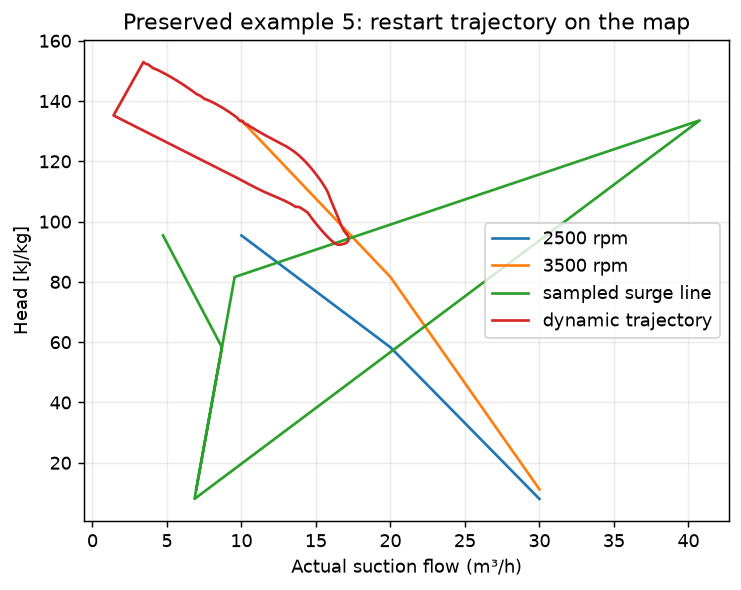

In [29]:
import numpy as np
flow1 = []
head1 = []
head2 = []
surge = []
for i in range(10, 40, 10):
    flow1.append(i)
    head1.append(compressor1.getCompressorChart().getPolytropicHead(i, 2500))
    head2.append(compressor1.getCompressorChart().getPolytropicHead(i, 3500))
sorted_head_values = np.sort(np.array(head1 + head2))
for i in head1 + head2:
    surge.append(compressor1.getCompressorChart().getSurgeCurve().getSurgeFlow(i))
plt.plot(flow1, head1, label='2500 rpm')
plt.plot(flow1, head2, label='3500 rpm')
plt.plot(surge, head1 + head2, label='sampled surge line')
plt.plot(flow, head, label='dynamic trajectory')
plt.legend()
plt.xlabel('Actual suction flow (m³/h)')
plt.ylabel('Head [kJ/kg]')
plt.title('Preserved example 5: restart trajectory on the map')
plt.grid(alpha=0.25)
plt.show()


### Interpretation of the preserved workflows

- The speed-step example shows the expected pressure and flow redistribution.
- Pressure control changes speed gradually because the gas inventories introduce dynamic lag.
- Closing the feed valve pushes the compressor toward surge and opens recycle.
- Combined pressure and anti-surge loops interact through the same compressor operating point.
- Depressurization and restart traverse a much wider portion of the map than steady turndown.

The native `AntiSurge` application earlier in the notebook supplies the clearest reusable API workflow. These retained process examples add system inventory, generic transmitters/controllers, and startup context without being reduced or hidden.

## 23. Engineering interpretation

- The base point is comfortably between generated surge and stone-wall boundaries.
- Without recycle, the 5 kg/s turndown crosses the surge line.
- Native proportional `AntiSurge` logic opens the valve before the operating point reaches surge and maintains a positive transient margin.
- The flow through the compressor exceeds fresh export flow during turndown, which is the central anti-surge mechanism.
- Larger recycle capacity improves settled margin but increases recycled compression work.
- Recovery closes the recycle valve and returns the machinery toward its initial speed, flow, and power.

The practical design decision is not simply “enable anti-surge.” Engineers must validate the control-line allowance, valve capacity and stroking time, cooler and piping pressure losses, speed-control interaction, trip logic, and actual vendor map.

## 24. Troubleshooting

- **No active margins:** generate surge and stone-wall curves before calling margin methods.
- **Unexpected point outside the chart:** confirm suction volumetric units, corrected-flow basis, speed units, and vendor reference conditions.
- **Valve opens too late:** review the control factor, warning margin, controller strategy, valve response time, and recycle capacity.
- **Oscillatory valve command:** reduce gain, lengthen response time, reduce time step, and check measurement filtering.
- **Unrealistic discharge temperature:** confirm gas composition, inlet state, efficiency, chart head unit, and whether an intercooler belongs in the model.
- **Colab starts from stale state:** restart the runtime and execute all cells in order; do not run only the dynamic section.

## 25. Summary and further exercises

This tutorial connected NeqSim 3.16.0 SRK thermodynamics, a generated `EXPORT` compressor chart, native surge and stone-wall calculations, native `AntiSurge` strategies, operating history, and operating-point JSON to a reproducible turndown and recycle-control workflow.

Further exercises:

1. replace the generated chart with public or vendor-authorized corrected curves;
2. add suction-pressure and molecular-weight disturbances;
3. compare `PID`, `PREDICTIVE`, and `DUAL_LOOP` tuning in the closed loop;
4. add recycle-cooler and valve pressure-drop calculations;
5. model a compressor trip, coast-down, restart permissives, and surge-cycle counter;
6. size the recycle valve and verify stroking time with project criteria.

## 26. Authoritative references

- [NeqSim compressor equipment](https://equinor.github.io/neqsim/process/equipment/compressors.html)
- [NeqSim compressor curves and performance maps](https://equinor.github.io/neqsim/process/equipment/compressor_curves.html)
- [NeqSim dynamic simulation guide](https://equinor.github.io/neqsim/simulation/dynamic_simulation_guide.html)
- [NeqSim process simulation package](https://equinor.github.io/neqsim/process/README.html)
- API 617, *Axial and Centrifugal Compressors and Expander-compressors*, for project machinery requirements.

Documentation can describe capabilities newer than the installed PyPI release. This notebook only calls APIs that were probed and executed successfully with NeqSim 3.16.0.